# Paper-ready simulation plots

Expected inputs: `results/presentation_simulation_summary.json`, `results/reanchor_ablation_summary.json`, and, for the convergence plot, `results/convergence_likelihood_T800_ours.json`. To regenerate them, run `python run_simulation.py --experiment presentation`, `python run_simulation.py --experiment reanchor_ablation`, and `python run_simulation.py --experiment convergence_likelihood` from this directory.

Expected inputs: `results/presentation_simulation_summary.json` and, for the convergence plot, `results/convergence_likelihood_T800_ours.json`. To regenerate them, run `python run_simulation.py --experiment presentation` and `python run_simulation.py --experiment convergence_likelihood` from this directory.

In [115]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

from IPython.display import Image, display

## Locate experiment files

In [116]:
cwd = Path.cwd().resolve()
if (cwd / "run_simulation.py").exists():
    EXPERIMENTS_DIR = cwd
elif (cwd / "experiments" / "run_simulation.py").exists():
    EXPERIMENTS_DIR = cwd / "experiments"
else:
    raise FileNotFoundError("Run this notebook from the repo root or the experiments directory.")

if str(EXPERIMENTS_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_DIR))

from run_simulation import (
    run_likelihood_convergence_experiment,
)

RESULTS_DIR = EXPERIMENTS_DIR / "results"
SUMMARY_PATH = RESULTS_DIR / "presentation_simulation_summary.json"
CONVERGENCE_SUMMARY_PATH = RESULTS_DIR / "convergence_likelihood_T800_ours.json"
OUTPUT_DIR = RESULTS_DIR / "paper_ready_simulation_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("EXPERIMENTS_DIR:", EXPERIMENTS_DIR)
print("SUMMARY_PATH:", SUMMARY_PATH)
print("CONVERGENCE_SUMMARY_PATH:", CONVERGENCE_SUMMARY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


EXPERIMENTS_DIR: /home/jinhongd/projects/HJA-Ranking/experiments
SUMMARY_PATH: /home/jinhongd/projects/HJA-Ranking/experiments/results/presentation_simulation_summary.json
CONVERGENCE_SUMMARY_PATH: /home/jinhongd/projects/HJA-Ranking/experiments/results/convergence_likelihood_T800_ours.json
OUTPUT_DIR: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots


In [117]:
import seaborn as sns
from matplotlib.lines import Line2D

METHOD_LABELS = {
    "proposed": "HJA",
    "direct_score_svd": "Unstructured BTL + SVD",
    "zhou_github": "JA-Ranking",
    "standard_btl": "Standard BTL",
}

METHOD_COLORS = {
    "proposed": "#0072B2",
    "direct_score_svd": "#CC79A7",
    "zhou_github": "#D55E00",
    "standard_btl": "#009E73",
}

PRESENTATION_METRICS = ("mse", "spearman", "ndcg", "score_entry_coverage", "sign_accuracy")

PRESENTATION_MARKERS = {
    "proposed": "o",
    "direct_score_svd": "D",
    "zhou_github": "s",
    "standard_btl": "^",
}

# Column titles — plain strings (metric + direction indicator moved to y-labels)
COL_SPECS = [
    "Score recovery",
    "Consensus ranking",
    "Consensus ranking",
    "Uncertainty calibration",
    "Judge-specific behavior",
]

# Y-axis labels: (label text with arrow, label color)
# ↓ red = lower is better;  ↑ green = higher is better
Y_LABEL_SPECS = [
    ("MSE ↓",       "#E74C3C"),
    ("Spearman ↑",  "#27AE60"),
    ("NDCG@N ↑",    "#27AE60"),
    ("Coverage ↑",  "#27AE60"),
    ("Accuracy ↑",  "#27AE60"),
]

X_LABEL_SAMPLE_SIZE = r"Number of comparisons $n_{\mathrm{cmp}}$"
X_LABEL_HETEROGENEITY = r"Heterogeneity scale $h$"

_TITLE_Y = 1.01  # axes-fraction y for custom titles


def legend_title_left(leg):
    """Move the legend title to the left of the items (same row)."""
    c = leg.get_children()[0]
    title = c.get_children()[0]
    hpack = c.get_children()[1]
    c._children = [hpack]
    hpack._children = [title] + hpack.get_children()


def apply_presentation_plot_style():
    sns.set_theme(
        style="ticks",
        context="paper",
        font="DejaVu Sans",
        rc={
            "font.size": 11.0,
            "axes.titlesize": 13.0,
            "axes.labelsize": 11.5,
            "axes.linewidth": 0.8,
            "xtick.labelsize": 10.5,
            "ytick.labelsize": 10.5,
            "legend.fontsize": 10.0,
            "figure.titlesize": 13.0,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.04,
        },
    )


def polish_presentation_axis(ax):
    ax.grid(True, color="#B0B0B0", linewidth=0.45, alpha=0.35)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", length=3, width=0.7)
    sns.despine(ax=ax)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#333333")
        ax.spines[spine].set_linewidth(0.8)


def set_panel_title(ax, title, fontsize=13.0):
    """Set a plain panel title; pass '' to suppress."""
    ax.set_title(title, fontsize=fontsize, color="#222222", pad=4)


def plot_metric_panel(ax, x_values, series, metric_name, x_label, y_label, title_spec, ylim=None):
    for method_name in METHOD_LABELS:
        ax.errorbar(
            x_values,
            series[method_name][metric_name]["mean"],
            yerr=series[method_name][metric_name]["err"],
            marker=PRESENTATION_MARKERS[method_name],
            markersize=4.6,
            linewidth=1.8,
            capsize=2.5,
            capthick=0.9,
            elinewidth=0.9,
            label=METHOD_LABELS[method_name],
            color=METHOD_COLORS[method_name],
        )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    set_panel_title(ax, title_spec)
    if ylim is not None:
        ax.set_ylim(*ylim)
    polish_presentation_axis(ax)


def presentation_series_from_conditions(conditions, x_key):
    series = {
        method_name: {metric: {"mean": [], "err": [], "n_success": []} for metric in PRESENTATION_METRICS}
        for method_name in METHOD_LABELS
    }
    x_values = []
    for condition in conditions:
        x_values.append(condition[x_key])
        for method_name in METHOD_LABELS:
            for metric_name in PRESENTATION_METRICS:
                metric_summary = condition["summary"][method_name][metric_name]
                series[method_name][metric_name]["mean"].append(
                    np.nan if metric_summary["mean"] is None else metric_summary["mean"]
                )
                series[method_name][metric_name]["err"].append(
                    np.nan if metric_summary["mc_ci95"] is None else metric_summary["mc_ci95"]
                )
                series[method_name][metric_name]["n_success"].append(metric_summary["n_success"])
    return np.asarray(x_values, dtype=float), series


def plot_presentation_grid(summary, save_path, dgp):
    apply_presentation_plot_style()
    if dgp == "ours":
        fig, axes = plt.subplots(2, 5, figsize=(16.5, 6.0), squeeze=False)
        row_specs = [
            ("ours_sample_size", "T", X_LABEL_SAMPLE_SIZE, True),
            ("ours_heterogeneity", "heterogeneity_scale", X_LABEL_HETEROGENEITY, False),
        ]
    elif dgp == "zhou":
        fig, axes = plt.subplots(1, 5, figsize=(16.5, 3.1), squeeze=False)
        row_specs = [("zhou_sample_size", "T", X_LABEL_SAMPLE_SIZE, True)]
    else:
        raise ValueError(f"unknown plot DGP: {dgp}")

    col_configs = [
        ("mse",                  (0,10)        ),
        ("spearman",             (0.6, 1)      ),
        ("ndcg",                 (0.9, 1)      ),
        ("score_entry_coverage", (-0.05, 1.05) ),
        ("sign_accuracy",        (-0.05, 1.05) ),
    ]

    for row_idx, (section_key, x_key, x_label, show_title) in enumerate(row_specs):
        x_values, series = presentation_series_from_conditions(summary[section_key], x_key)
        specs = COL_SPECS if show_title else [""] * 5

        for col_idx, (metric_name, ylim) in enumerate(col_configs):
            y_lbl, y_color = Y_LABEL_SPECS[col_idx]
            plot_metric_panel(
                axes[row_idx, col_idx], x_values, series,
                metric_name, x_label, y_lbl, specs[col_idx], ylim=ylim,
            )
            axes[row_idx, col_idx].yaxis.label.set_color(y_color)

        # 95 % nominal coverage reference line
        axes[row_idx, 3].axhline(0.95, color="#4D4D4D", linestyle="--", linewidth=0.9, alpha=0.8)
        axes[row_idx, 3].text(
            0.02, 0.04,
            "Unstructured BTL + SVD coverage omitted: no simple interval formula after truncated SVD.",
            transform=axes[row_idx, 3].transAxes,
            fontsize=6.5,
            color="#555555",
            va="bottom",
        )

    method_handles = [
        Line2D(
            [0], [0],
            color=METHOD_COLORS[m],
            marker=PRESENTATION_MARKERS[m],
            linewidth=1.8, markersize=4.6,
            label=METHOD_LABELS[m],
        )
        for m in METHOD_LABELS
    ]
    fig.tight_layout(w_pad=1.0, h_pad=1.5, rect=(0, 0, 1, 0.91))
    leg = fig.legend(
        handles=method_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(method_handles),
        frameon=False,
        columnspacing=1.4,
        handlelength=1.8,
        title="Methods",
        title_fontsize=13.0,
    )
    legend_title_left(leg)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    # plt.close(fig)
    plt.show()
    return save_path


## Load saved simulation summary

In [118]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing {SUMMARY_PATH}. Run `python run_simulation.py --experiment presentation` first."
    )

with SUMMARY_PATH.open("r", encoding="utf-8") as f:
    summary = json.load(f)

required_sections = ["ours_sample_size", "ours_heterogeneity", "zhou_sample_size"]
missing = [section for section in required_sections if section not in summary]
if missing:
    raise KeyError(f"Summary is missing required sections: {missing}")

{section: len(summary[section]) for section in required_sections}

{'ours_sample_size': 7, 'ours_heterogeneity': 4, 'zhou_sample_size': 7}

## 2-by-4 plot: ours DGP

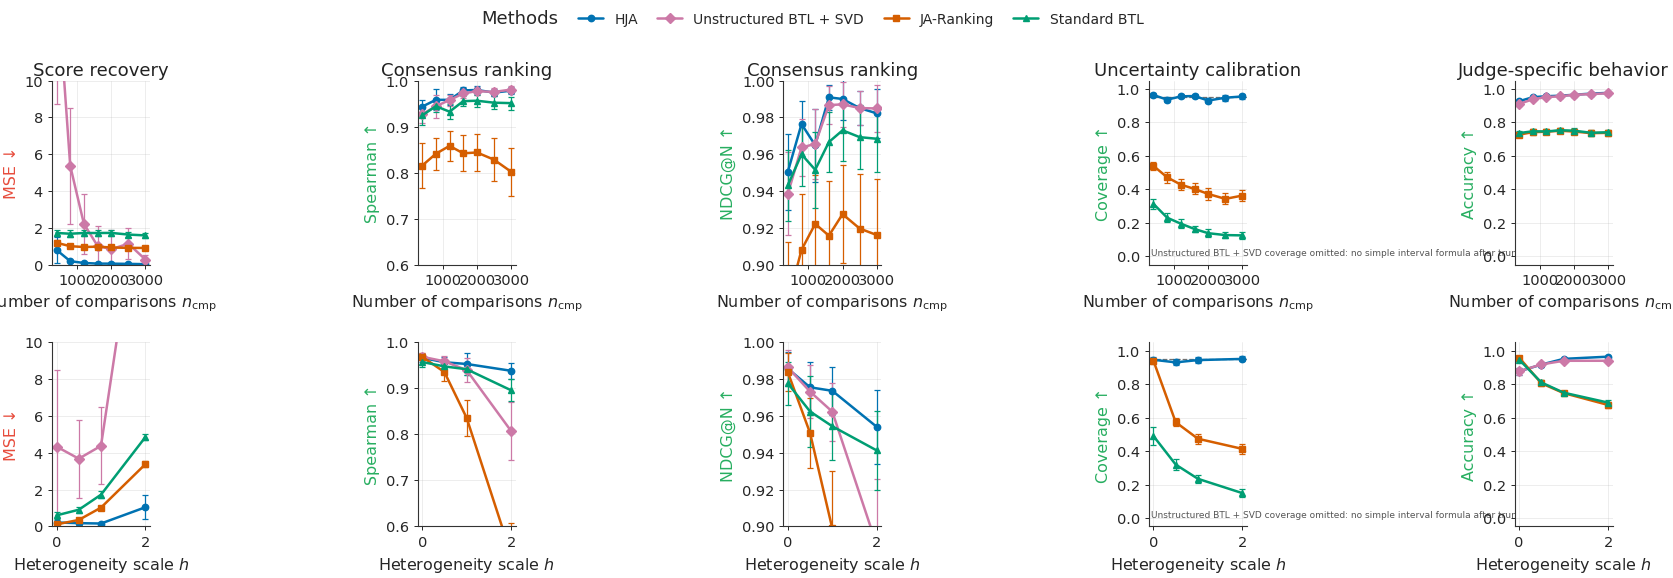

PosixPath('/home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_presentation_ours_dgp_grid.pdf')

In [119]:
ours_pdf = OUTPUT_DIR / "paper_ready_presentation_ours_dgp_grid.pdf"
plot_presentation_grid(summary, ours_pdf, "ours")

## 1-by-4 plot: Zhou DGP

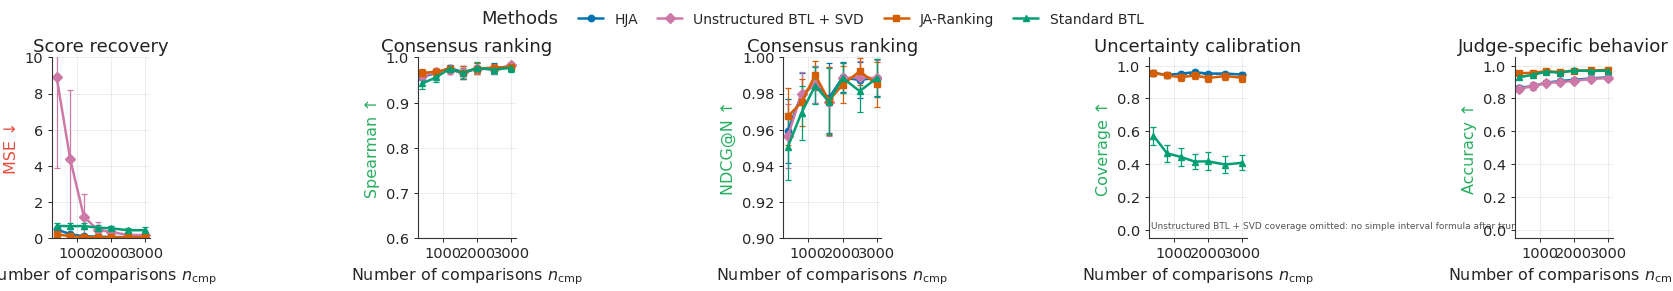

PosixPath('/home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_presentation_zhou_dgp_grid.pdf')

In [120]:
zhou_pdf = OUTPUT_DIR / "paper_ready_presentation_zhou_dgp_grid.pdf"
plot_presentation_grid(summary, zhou_pdf, "zhou")

## ReAnchor ablation plot

This block redraws the 2-by-4 ablation figure comparing the proposed model, the direct-S truncated-SVD method, and the proposed model without the per-iteration ReAnchor step.

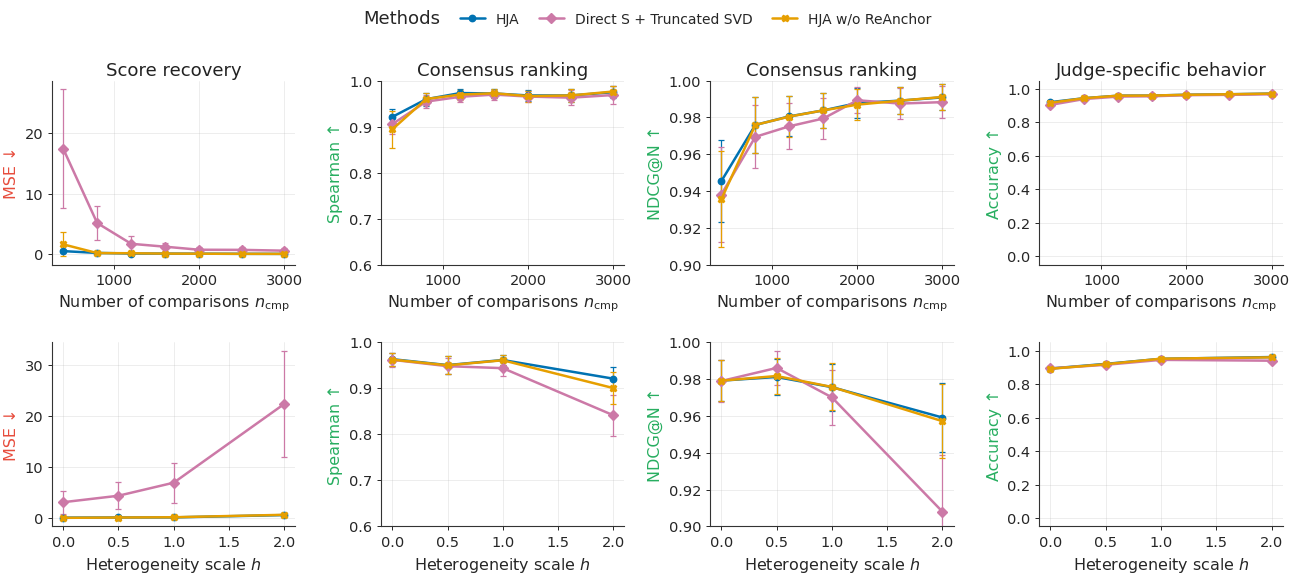

PosixPath('/home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_reanchor_ablation_grid.pdf')

In [121]:
ABLATION_SUMMARY_PATH = RESULTS_DIR / "reanchor_ablation_summary.json"
if not ABLATION_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing {ABLATION_SUMMARY_PATH}. Run `python run_simulation.py --experiment reanchor_ablation` first."
    )

with ABLATION_SUMMARY_PATH.open("r", encoding="utf-8") as f:
    ablation_summary = json.load(f)

ABLATION_METHOD_LABELS = {
    "proposed": "HJA",
    "direct_score_svd": "Direct S + Truncated SVD",
    "proposed_no_reanchor": "HJA w/o ReAnchor",
}

ABLATION_METHOD_COLORS = {
    "proposed": "#0072B2",
    "direct_score_svd": "#CC79A7",
    "proposed_no_reanchor": "#E69F00",
}

ABLATION_MARKERS = {
    "proposed": "o",
    "direct_score_svd": "D",
    "proposed_no_reanchor": "X",
}

ABLATION_METRICS = ("mse", "spearman", "ndcg", "sign_accuracy")
ABLATION_COL_SPECS = [
    "Score recovery",
    "Consensus ranking",
    "Consensus ranking",
    "Judge-specific behavior",
]
ABLATION_Y_LABEL_SPECS = [
    ("MSE ↓", "#E74C3C"),
    ("Spearman ↑", "#27AE60"),
    ("NDCG@N ↑", "#27AE60"),
    ("Accuracy ↑", "#27AE60"),
]


def ablation_series_from_conditions(conditions, x_key):
    series = {
        method_name: {metric: {"mean": [], "err": [], "n_success": []} for metric in ABLATION_METRICS}
        for method_name in ABLATION_METHOD_LABELS
    }
    x_values = []
    for condition in conditions:
        x_values.append(condition[x_key])
        for method_name in ABLATION_METHOD_LABELS:
            for metric_name in ABLATION_METRICS:
                metric_summary = condition["summary"][method_name][metric_name]
                series[method_name][metric_name]["mean"].append(
                    np.nan if metric_summary["mean"] is None else metric_summary["mean"]
                )
                series[method_name][metric_name]["err"].append(
                    np.nan if metric_summary["mc_ci95"] is None else metric_summary["mc_ci95"]
                )
                series[method_name][metric_name]["n_success"].append(metric_summary["n_success"])
    return np.asarray(x_values, dtype=float), series


def plot_reanchor_ablation_grid(summary, pdf_path, png_path=None):
    apply_presentation_plot_style()
    fig, axes = plt.subplots(2, 4, figsize=(13.2, 6.0), squeeze=False)
    row_specs = [
        ("ours_sample_size", "T", X_LABEL_SAMPLE_SIZE, True),
        ("ours_heterogeneity", "heterogeneity_scale", X_LABEL_HETEROGENEITY, False),
    ]
    col_configs = [
        ("mse", None),
        ("spearman", (0.6, 1)),
        ("ndcg", (0.9, 1)),
        ("sign_accuracy", (-0.05, 1.05)),
    ]

    for row_idx, (section_key, x_key, x_label, show_title) in enumerate(row_specs):
        x_values, series = ablation_series_from_conditions(summary[section_key], x_key)
        specs = ABLATION_COL_SPECS if show_title else [""] * 4
        for col_idx, (metric_name, ylim) in enumerate(col_configs):
            ax = axes[row_idx, col_idx]
            for method_name in ABLATION_METHOD_LABELS:
                ax.errorbar(
                    x_values,
                    series[method_name][metric_name]["mean"],
                    yerr=series[method_name][metric_name]["err"],
                    marker=ABLATION_MARKERS[method_name],
                    markersize=4.6,
                    linewidth=1.8,
                    capsize=2.5,
                    capthick=0.9,
                    elinewidth=0.9,
                    label=ABLATION_METHOD_LABELS[method_name],
                    color=ABLATION_METHOD_COLORS[method_name],
                )
            y_lbl, y_color = ABLATION_Y_LABEL_SPECS[col_idx]
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_lbl)
            ax.yaxis.label.set_color(y_color)
            set_panel_title(ax, specs[col_idx])
            if ylim is not None:
                ax.set_ylim(*ylim)
            polish_presentation_axis(ax)

    method_handles = [
        Line2D(
            [0], [0],
            color=ABLATION_METHOD_COLORS[m],
            marker=ABLATION_MARKERS[m],
            linewidth=1.8, markersize=4.6,
            label=ABLATION_METHOD_LABELS[m],
        )
        for m in ABLATION_METHOD_LABELS
    ]
    fig.tight_layout(w_pad=1.0, h_pad=1.5, rect=(0, 0, 1, 0.91))
    leg = fig.legend(
        handles=method_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(method_handles),
        frameon=False,
        columnspacing=1.4,
        handlelength=1.8,
        title="Methods",
        title_fontsize=13.0,
    )
    legend_title_left(leg)
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    if png_path is not None:
        fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pdf_path


ablation_pdf = OUTPUT_DIR / "paper_ready_reanchor_ablation_grid.pdf"
ablation_png = OUTPUT_DIR / "paper_ready_reanchor_ablation_grid.png"
plot_reanchor_ablation_grid(ablation_summary, ablation_pdf, ablation_png)


## Convergence plot: negative log-likelihood

This plot uses one repetition trace from the saved convergence summary, without averaging across repetitions or drawing error bars. The plotting function is defined in the notebook so the figure style can be edited directly.

### Editable plotting function

In [122]:
def get_likelihood_trace(summary, repetition_index=0):
    traces = summary.get("traces", [])
    if not traces:
        raise ValueError("No successful likelihood traces were recorded.")
    for trace in traces:
        if trace.get("rep") == repetition_index:
            return trace
    if repetition_index == 0:
        return traces[0]
    raise ValueError(f"Repetition {repetition_index} is not available.")


def _style_convergence_ax(ax):
    """Apply shared axis styling for convergence panels."""
    ax.grid(True, color="#D0D0D0", linewidth=0.45, alpha=0.55)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", length=2.5, width=0.7, pad=2)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#333333")
        ax.spines[spine].set_linewidth(0.75)


def plot_convergence_trace(
    summary,
    save_path=None,
    repetition_index=0,
    figsize=(3.35, 2.25),
    color="#0072B2",
    marker="o",
    linewidth=1.65,
    markersize=3.8,
    title=None,
):
    trace = get_likelihood_trace(summary, repetition_index=repetition_index)
    nll_full = np.asarray(trace["nll"], dtype=float)
    if nll_full.size < 2:
        raise ValueError("Need at least two iterations to start the convergence plot at iteration 2.")
    nll = nll_full[1:]
    iterations = np.arange(2, nll_full.size + 1)
    if nll_full[-1] > nll_full[0]:
        raise ValueError(
            f"Selected trace increases from {nll_full[0]:.6f} to {nll_full[-1]:.6f}; "
            "check the saved convergence summary."
        )

    rc = {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8.5,
        "axes.titlesize": 8.5,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "axes.linewidth": 0.75,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }
    with plt.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(
            iterations,
            nll,
            color=color,
            marker=marker,
            linewidth=linewidth,
            markersize=markersize,
            markeredgewidth=0.7,
            markeredgecolor="white",
        )
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Negative log-likelihood")
        if title:
            ax.set_title(title)
        ax.set_xlim(2, int(iterations[-1]))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        y_pad = 0.04 * max(float(np.ptp(nll)), 1.0)
        ax.set_ylim(float(np.min(nll) - y_pad), float(np.max(nll) + y_pad))
        _style_convergence_ax(ax)
        fig.tight_layout(pad=0.4)
        if save_path is not None:
            fig.savefig(save_path, dpi=600)
    return fig, ax, trace


def plot_convergence_multi_panel(
    summary,
    save_path=None,
    repetition_index=0,
    figsize=(6.9, 2.25),
):
    """Three-panel convergence figure.

    (a) NLL trace for one representative run — monotone decrease.
    (b) Normalized excess NLL for all repetitions (log-y) — consistency
        and geometric convergence rate across random seeds.
    (c) Histogram of iterations-to-convergence — algorithm is fast.
    """
    traces = summary.get("traces", [])
    if not traces:
        raise ValueError("No successful likelihood traces were recorded.")
    selected = get_likelihood_trace(summary, repetition_index=repetition_index)

    rc = {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8.5,
        "axes.titlesize": 8.5,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "axes.linewidth": 0.75,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
    }

    highlight_color = "#0072B2"
    bg_color = "#AAAAAA"

    with plt.rc_context(rc):
        fig, axes = plt.subplots(1, 3, figsize=figsize)

        # ── Panel (a): single trace NLL ───────────────────────────────────
        ax = axes[0]
        nll_full = np.asarray(selected["nll"], dtype=float)
        nll = nll_full[1:]
        iters_a = np.arange(2, nll_full.size + 1)
        ax.plot(iters_a, nll, color=highlight_color, marker="o",
                linewidth=1.65, markersize=3.8,
                markeredgewidth=0.7, markeredgecolor="white")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Negative log-likelihood")
        ax.set_title("(a) Single run")
        ax.set_xlim(2, int(iters_a[-1]))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        y_pad = 0.04 * max(float(np.ptp(nll)), 1.0)
        ax.set_ylim(float(np.min(nll) - y_pad), float(np.max(nll) + y_pad))
        _style_convergence_ax(ax)

        # ── Panel (b): all traces — normalized excess NLL (log-y) ─────────
        ax = axes[1]
        max_iter_all = max(t["n_iter"] for t in traces)
        for t in traces:
            nll_t = np.asarray(t["nll"], dtype=float)
            nll_min = nll_t[-1]
            nll_range = nll_t[0] - nll_min
            if nll_range <= 0:
                continue
            excess = (nll_t - nll_min) / nll_range  # 1 → 0
            iters_t = np.arange(1, len(nll_t) + 1)
            is_selected = (t.get("rep") == repetition_index)
            ax.plot(iters_t, np.clip(excess, 1e-6, None),
                    color=highlight_color if is_selected else bg_color,
                    linewidth=1.5 if is_selected else 0.55,
                    alpha=1.0 if is_selected else 0.35,
                    zorder=10 if is_selected else 1)
        # Add a proxy for the legend
        from matplotlib.lines import Line2D as _L2D
        ax.legend(
            handles=[
                _L2D([0], [0], color=bg_color, linewidth=0.8, alpha=0.6, label=f"All repetitions (n={len(traces)})"),
                _L2D([0], [0], color=highlight_color, linewidth=1.5, label=f"Rep {repetition_index}"),
            ],
            fontsize=6.5, frameon=False, loc="upper right",
        )
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Normalized excess NLL")
        ax.set_title("(b) All repetitions")
        ax.set_xlim(1, max_iter_all)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        _style_convergence_ax(ax)

        # ── Panel (c): histogram of iterations to convergence ─────────────
        ax = axes[2]
        n_iters = [t["n_iter"] for t in traces]
        bins = np.arange(min(n_iters) - 0.5, max(n_iters) + 1.5, 1)
        counts, edges = np.histogram(n_iters, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.bar(centers, counts, width=0.75, color=highlight_color, alpha=0.80,
               edgecolor="white", linewidth=0.5)
        # Annotate median
        med = float(np.median(n_iters))
        ax.axvline(med, color="#D55E00", linewidth=1.2, linestyle="--",
                   label=f"Median = {int(med)}")
        ax.legend(fontsize=6.5, frameon=False)
        ax.set_xlabel("Iterations to convergence")
        ax.set_ylabel("Count")
        ax.set_title("(c) Convergence speed")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        _style_convergence_ax(ax)

        fig.tight_layout(pad=0.5, w_pad=1.8)
        if save_path is not None:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, axes, selected


Wrote: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_convergence_likelihood_T800_ours.png
Wrote: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_convergence_likelihood_T800_ours.pdf
Selected repetition: 0
Seed: 9000
Iterations: 13
NLL: 355.279 -> 341.487
Traces in summary: 50


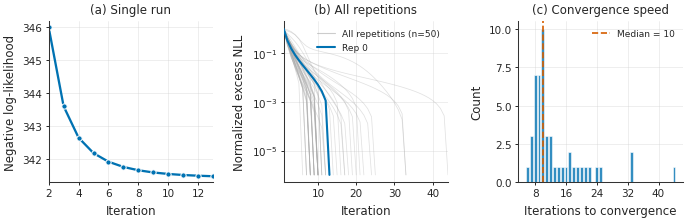

In [123]:
if not CONVERGENCE_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CONVERGENCE_SUMMARY_PATH}. Run `python run_simulation.py --experiment convergence_likelihood` first, "
        "or run the optional regeneration cell below."
    )

with CONVERGENCE_SUMMARY_PATH.open("r", encoding="utf-8") as f:
    convergence_summary = json.load(f)

REPETITION_INDEX = 0
convergence_png = OUTPUT_DIR / "paper_ready_convergence_likelihood_T800_ours.png"
convergence_pdf = OUTPUT_DIR / "paper_ready_convergence_likelihood_T800_ours.pdf"

# Multi-panel figure (panels a, b, c)
fig, axes_mp, selected_trace = plot_convergence_multi_panel(
    convergence_summary,
    save_path=convergence_png,
    repetition_index=REPETITION_INDEX,
)
fig_pdf, _, _ = plot_convergence_multi_panel(
    convergence_summary,
    save_path=convergence_pdf,
    repetition_index=REPETITION_INDEX,
)
plt.close(fig_pdf)

nll_values = selected_trace["nll"]
print("Wrote:", convergence_png)
print("Wrote:", convergence_pdf)
print("Selected repetition:", selected_trace["rep"])
print("Seed:", selected_trace["seed"])
print("Iterations:", selected_trace["n_iter"])
print(f"NLL: {nll_values[0]:.3f} -> {nll_values[-1]:.3f}")
print(f"Traces in summary: {len(convergence_summary['traces'])}")


## Optional: regenerate convergence summary

Run this cell only if you want the notebook to refit the repeated simulations before plotting one selected convergence trace.

In [124]:
# convergence_summary = run_likelihood_convergence_experiment(T=800, n_repeats=50)
# plot_convergence_trace(
#     convergence_summary,
#     save_path=OUTPUT_DIR / "paper_ready_convergence_likelihood_T800_ours.png",
#     repetition_index=0,
# )
# plot_convergence_trace(
#     convergence_summary,
#     save_path=OUTPUT_DIR / "paper_ready_convergence_likelihood_T800_ours.pdf",
#     repetition_index=0,
# )

## Real dataset analysis

We apply our model on UltraFeedback and derive the ranking of the models, as well as their confidence region. We also report the gamma's of judges.

In [125]:
import pandas as pd
from src.generate_data import load_real_dataset, processed_records_to_aggregated
from src.benchmarks import fit_proposed
from src.models import uncertainty_quantification

# Load ChatBot Arena dataset
print("Loading ChatBot Arena dataset...")
CHATBOT_ARENA_PATH = EXPERIMENTS_DIR / "data" / "judge_results_10k_chatbot_arena.json"
dataset = load_real_dataset(str(CHATBOT_ARENA_PATH))

summary = dataset["summary"]
processed_records = dataset["processed"]
item_names = dataset["item_names"]
judge_names = dataset["judge_names"]
N = len(item_names)  # number of items
K = len(judge_names)  # number of judges

print(f"\nDataset Summary:")
print(f"  Total raw records: {summary['total_records']}")
print(f"  Usable records: {summary['usable_records']}")
print(f"  Number of judges (K): {K}")
print(f"  Number of items (N): {N}")

# Convert to aggregated format
n_ijk, y_ijk = processed_records_to_aggregated(processed_records, N, K)

# From prior analysis (cross-validation): ChatBot Arena selected rank = 1
# See: results/bootstrap_summaries/bootstrap_summary_chatbot_arena_samples_500.json
r_model = 1
print(f"\nUsing rank r={r_model} (from prior cross-validation analysis)")

print(f"\nFitting proposed method with rank r={r_model}...")
fit_proposed_result = fit_proposed(N, K, r_model, n_ijk, y_ijk, max_steps=40, tol=5e-5, tau=30.0)

# Extract components
mu_est = fit_proposed_result["mu"]
gamma_est = fit_proposed_result["gamma"]
U_est = fit_proposed_result["U"]
V_est = fit_proposed_result["V"]
S_est = fit_proposed_result["S"]

print(f"  mu shape: {mu_est.shape}")
print(f"  gamma shape: {gamma_est.shape}")
print(f"  U shape: {U_est.shape}")
print(f"  V shape: {V_est.shape}")
print(f"  S shape: {S_est.shape}")

# Compute confidence intervals for consensus scores (mu) using UQ method
print(f"\nComputing confidence intervals for model scores (alpha=0.05)...")
targets = [{"type": "consensus_score", "i": i, "label": f"mu[{i}]"} for i in range(N)]
uq_results = uncertainty_quantification(gamma_est, mu_est, U_est, V_est, n_ijk, targets, alpha=0.05)

# Extract 95% confidence-interval half-widths for each score
half_ci_by_label = {}
for interval in uq_results["intervals"]:
    label = interval["label"]
    half_ci_by_label[label] = 0.5 * (interval["upper"] - interval["lower"])

# Create ranking table with confidence intervals
ranking_data = []
for idx, model in enumerate(item_names):
    score = mu_est[idx]
    half_ci = half_ci_by_label.get(f"mu[{idx}]", 0.0)
    
    ranking_data.append({
        "Model": model,
        "Score": f"${score:.4f} \\pm {half_ci:.4f}$",
        "Score value": score,
        "Half CI": half_ci,
    })

ranking_df = pd.DataFrame(ranking_data)
ranking_df = ranking_df.sort_values("Score value", ascending=False).reset_index(drop=True)
ranking_df["Rank"] = range(1, len(ranking_df) + 1)
ranking_df = ranking_df[["Rank", "Model", "Score"]]

print("\nModel Rankings with 95% Confidence Intervals (from ChatBot Arena):")
print(ranking_df.to_string(index=False))

Loading ChatBot Arena dataset...

Dataset Summary:
  Total raw records: 10000
  Usable records: 9937
  Number of judges (K): 10
  Number of items (N): 20

Using rank r=1 (from prior cross-validation analysis)

Fitting proposed method with rank r=1...
  mu shape: (20,)
  gamma shape: (10,)
  U shape: (10, 1)
  V shape: (20, 1)
  S shape: (10, 20)

Computing confidence intervals for model scores (alpha=0.05)...

Model Rankings with 95% Confidence Intervals (from ChatBot Arena):
 Rank                   Model                Score
    1       claude-instant-v1  $1.5421 \pm 0.1671$
    2               claude-v1  $1.4800 \pm 0.1434$
    3                   gpt-4  $1.1475 \pm 0.1345$
    4           gpt-3.5-turbo  $0.8104 \pm 0.1220$
    5        RWKV-4-Raven-14B  $0.4759 \pm 0.1771$
    6             guanaco-33b  $0.3481 \pm 0.2344$
    7              alpaca-13b  $0.2686 \pm 0.1380$
    8              chatglm-6b  $0.0394 \pm 0.1491$
    9      gpt4all-13b-snoozy $-0.1324 \pm 0.2217$
   10    

## Judge-specific parameters (gamma)

In [126]:
# Create judge gamma table with confidence intervals
gamma_targets = [{"type": "gamma", "k": k, "label": f"gamma[{k}]"} for k in range(K)]
gamma_uq_results = uncertainty_quantification(gamma_est, mu_est, U_est, V_est, n_ijk, gamma_targets, alpha=0.05)

gamma_half_ci_by_label = {}
for interval in gamma_uq_results["intervals"]:
    label = interval["label"]
    gamma_half_ci_by_label[label] = 0.5 * (interval["upper"] - interval["lower"])

gamma_data = []
for idx, judge in enumerate(judge_names):
    gamma = gamma_est[idx]
    half_ci = gamma_half_ci_by_label.get(f"gamma[{idx}]", 0.0)
    gamma_data.append({
        "Judge": judge,
        "Gamma": f"${gamma:.4f} \\pm {half_ci:.4f}$",
        "Gamma value": gamma,
        "Half CI": half_ci,
    })

gamma_df = pd.DataFrame(gamma_data)
gamma_df = gamma_df.sort_values("Gamma value", ascending=False).reset_index(drop=True)
gamma_df = gamma_df[["Judge", "Gamma"]]

print("\nJudge-specific parameters (gamma):")
print("Higher gamma indicates the judge has stronger discriminative power")
print(gamma_df.to_string(index=False))


Judge-specific parameters (gamma):
Higher gamma indicates the judge has stronger discriminative power
                                            Judge               Gamma
                          zai-org/GLM-4.5-Air-FP8 $3.4744 \pm 0.1919$
                               openai/gpt-oss-20b $1.2216 \pm 0.1768$
          Qwen/Qwen3-235B-A22B-Instruct-2507-tput $1.1150 \pm 0.1655$
                         arcee_ai/arcee-spotlight $0.9841 \pm 0.1490$
                           google/gemma-3n-E4B-it $0.9761 \pm 0.1554$
                             kimi-k2-0905-preview $0.9667 \pm 0.1525$
meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8 $0.8547 \pm 0.1490$
               mistralai/Mistral-7B-Instruct-v0.1 $0.1918 \pm 0.1206$
                marin-community/marin-8b-instruct $0.1177 \pm 0.1157$
                                    deepseek-chat $0.0980 \pm 0.1396$


## UV^T heterogeneous interaction terms heatmap

UV^T shape: (10, 20)
UV^T min: -5.9684, max: 7.2557

Removing judge: zai-org/GLM-4.5-Air-FP8 (index 9)
Filtered UV^T shape: (9, 20)
Filtered UV^T min: -1.9766, max: 1.6259

Clustered UV^T shape: (9, 20)



Wrote clustered UV^T heatmap to: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_chatbot_arena_uvt_heatmap.pdf


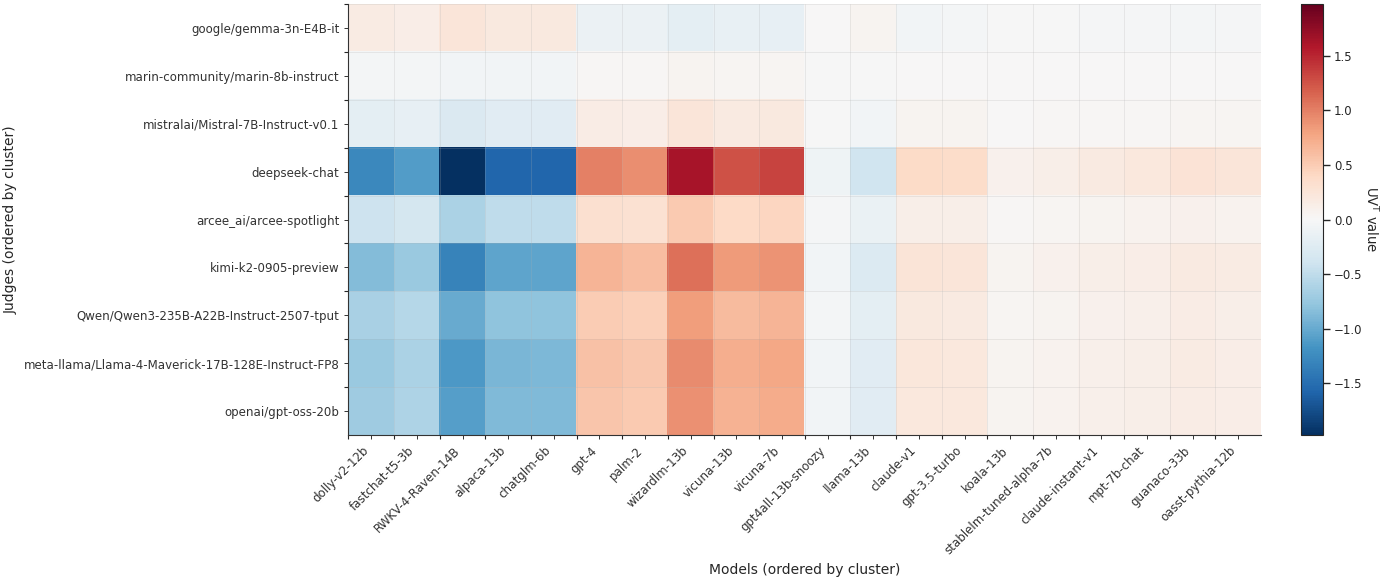

In [127]:
# Compute UV^T heterogeneous interaction term
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

UVT = U_est @ V_est.T
print(f"UV^T shape: {UVT.shape}")
print(f"UV^T min: {np.min(UVT):.4f}, max: {np.max(UVT):.4f}")

# Remove the extreme judge (zai-org/GLM-4.5-Air-FP8) for better visualization
extreme_judge_name = "zai-org/GLM-4.5-Air-FP8"
extreme_judge_idx = judge_names.index(extreme_judge_name)
print(f"\nRemoving judge: {extreme_judge_name} (index {extreme_judge_idx})")

# Filter out the extreme judge
filtered_judge_indices = [i for i in range(K) if i != extreme_judge_idx]
filtered_judge_names = [judge_names[i] for i in filtered_judge_indices]
UVT_filtered = UVT[filtered_judge_indices, :]

print(f"Filtered UV^T shape: {UVT_filtered.shape}")
print(f"Filtered UV^T min: {np.min(UVT_filtered):.4f}, max: {np.max(UVT_filtered):.4f}")

# Apply hierarchical clustering to both judges and models for better visualization
# Compute distances for clustering
judge_distances = pdist(UVT_filtered, metric='euclidean')
judge_linkage = linkage(judge_distances, method='ward')
judge_order = dendrogram(judge_linkage, no_plot=True)['leaves']

model_distances = pdist(UVT_filtered.T, metric='euclidean')
model_linkage = linkage(model_distances, method='ward')
model_order = dendrogram(model_linkage, no_plot=True)['leaves']

# Reorder UV^T matrix by clustering
UVT_clustered = UVT_filtered[judge_order, :][:, model_order]
clustered_judge_names = [filtered_judge_names[i] for i in judge_order]
clustered_model_names = [item_names[i] for i in model_order]

print(f"\nClustered UV^T shape: {UVT_clustered.shape}")

# Apply seaborn styling to match simulation plots
sns.set_theme(
    style="ticks",
    context="paper",
    font="DejaVu Sans",
    rc={
        "font.size": 9.0,
        "axes.labelsize": 10.0,
        "axes.titlesize": 11.0,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    },
)

# Create heatmap visualization with adjusted color scale
fig, ax = plt.subplots(figsize=(14, 6))

# Use symmetric colormap centered at 0 with adjusted vmin/vmax to exclude extreme values
vmax_filtered = np.max(np.abs(UVT_clustered))
vmin_filtered = -vmax_filtered

im = ax.imshow(UVT_clustered, aspect='auto', cmap='RdBu_r', origin='upper',
               vmin=vmin_filtered, vmax=vmax_filtered)

# Set labels for judges and items
ax.set_xticks(np.arange(len(clustered_model_names)))
ax.set_yticks(np.arange(len(clustered_judge_names)))
ax.set_xticklabels(clustered_model_names, rotation=45, ha='right', fontsize=8.5)
ax.set_yticklabels(clustered_judge_names, fontsize=8.5)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('UV$^\\mathrm{T}$ value', rotation=270, labelpad=12, fontsize=9.5)

# Set title and labels with consistent styling
#ax.set_title('Judge-Model Heterogeneous Interaction Terms (UV$^\\mathrm{T}$)\nClustered by Judge/Model Affinity (Extreme Judge Removed)', 
 #            fontsize=11, color="#222222", pad=8)
ax.set_xlabel('Models (ordered by cluster)', fontsize=10)
ax.set_ylabel('Judges (ordered by cluster)', fontsize=10)

# Apply seaborn despine and styling
sns.despine(ax=ax, left=False, bottom=False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', length=3, width=0.7, colors='#333333')

# Add grid
ax.set_xticks(np.arange(len(clustered_model_names))-.5, minor=True)
ax.set_yticks(np.arange(len(clustered_judge_names))-.5, minor=True)
ax.grid(which='minor', color='#B0B0B0', linestyle='-', linewidth=0.45, alpha=0.35)
ax.set_axisbelow(True)

fig.tight_layout()

# Save the figure
uvt_output_path = OUTPUT_DIR / "paper_ready_chatbot_arena_uvt_heatmap.pdf"
fig.savefig(uvt_output_path, dpi=300, bbox_inches='tight')
print(f"\nWrote clustered UV^T heatmap to: {uvt_output_path}")

plt.show()

## Composite ChatBot Arena figure

A single publication-ready figure with four aligned panels.
Layout is **transposed** (x = models, y = judges) because $N > K$, making the figure landscape-oriented:

| Panel | Position | Content |
|---|---|---|
| **(a)** | top-left | Model-family colour legend |
| **(b)** | top-right | Consensus score $\hat{\mu}_i$ ± 95 % CI — vertical bars, x = models (cluster-ordered), shared with (d) |
| **(c)** | bottom-left | Judge sensitivity $\hat{\gamma}_k$ ± 95 % CI — horizontal bars, y = judges (cluster-ordered), shared with (d) |
| **(d)** | bottom-right | $UV^\top$ heatmap — x = models, y = judges (both cluster-ordered) |

**What to look for**
- **(b)** Models whose 95 % CIs do **not** overlap are significantly ranked apart; bar colour encodes model family.
- **(c)** High $\hat{\gamma}_k$ → judge discriminates strongly; `*` marks CI strictly above 0; blue bars = contrarian/noisy judges.
- **(d)** Off-diagonal blocks reveal systematic judge–model affinity clusters beyond the consensus ranking — the key structural insight of HJA.


In [128]:
# ── Flatten CI dictionaries into ordered arrays ───────────────────────────────
mu_half_ci_arr    = np.array([half_ci_by_label.get(f"mu[{i}]",       0.0) for i in range(N)])
gamma_half_ci_arr = np.array([gamma_half_ci_by_label.get(f"gamma[{k}]", 0.0) for k in range(K)])

print(f"mu     half-CI  : min={mu_half_ci_arr.min():.4f}  max={mu_half_ci_arr.max():.4f}")
print(f"gamma  half-CI  : min={gamma_half_ci_arr.min():.4f}  max={gamma_half_ci_arr.max():.4f}")
print(f"mu     range    : [{mu_est.min():.4f}, {mu_est.max():.4f}]")
print(f"gamma  range    : [{gamma_est.min():.4f}, {gamma_est.max():.4f}]")


mu     half-CI  : min=0.1098  max=0.2344
gamma  half-CI  : min=0.1157  max=0.1919
mu     range    : [-1.2485, 1.5421]
gamma  range    : [0.0980, 3.4744]


In [129]:
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist


# ── Name helpers ──────────────────────────────────────────────────────────────

def _shorten(name: str, max_len: int = 22) -> str:
    """Shorten org/model names for axis labels."""
    if len(name) <= max_len:
        return name
    if "/" in name:
        org, _, tail = name.partition("/")
        short = f"{org}/{tail}"
        return short if len(short) <= max_len else tail[:max_len]
    return name[: max_len - 1] + "…"


# Priority-ordered: first match wins.
# 8 broad groups; colourblind-safe Paul Tol palette.
_FAMILY_KEYWORDS = [
    # ── Named large labs ─────────────────────────────────────────────────────
    ("OpenAI",          ["gpt", "openai", "chatgpt", "o1-", "o3-", "o4-", "/o1", "/o3", "/o4"]),
    ("Anthropic",       ["claude", "anthropic"]),
    ("Google",          ["gemini", "palm", "gemma", "google/", "google-", "bard"]),
    ("Meta",            ["llama", "meta-llama", "meta/"]),
    # ── Chinese AI labs (all merged) ─────────────────────────────────────────
    ("Chinese Labs",    ["qwen", "alibaba", "tongyi",        # Qwen / Alibaba
                         "deepseek",                         # DeepSeek
                         "chatglm", "glm-", "zai-org", "zhipu",  # ZhipuAI
                         "kimi", "moonshot",                 # Moonshot AI
                         "ernie", "baidu"]),                 # Baidu
    # ── Community fine-tunes (LLaMA / instruction-tuned) ─────────────────────
    ("Community",       ["alpaca", "vicuna", "guanaco", "koala", "fastchat",
                         "baize", "gpt4all", "wizardlm", "ultralm", "starchat",
                         "dolly", "databricks",              # Databricks
                         "arcee", "marin",                   # newer community
                         "deepcogito", "cogito",             # community fine-tunes
                         "arize"]),                          # Arize
    # ── Other open-source models ─────────────────────────────────────────────
    ("Open-Source",     ["mistral", "mixtral",               # Mistral
                         "falcon",                           # TII Falcon
                         "phi-", "microsoft/",               # Microsoft
                         "mpt-", "mosaicml",                 # MosaicML
                         "stablelm", "stability",            # StabilityAI
                         "oasst", "openassistant", "pythia",  # OpenAssistant
                         "rwkv"]),                           # RWKV
]

# Colourblind-friendly palette (Paul Tol)
_FAMILY_COLORS = {
    "OpenAI":       "#0072B2",   # blue
    "Anthropic":    "#E69F00",   # orange
    "Google":       "#009E73",   # teal
    "Meta":         "#CC79A7",   # pink
    "Chinese Labs": "#D55E00",   # vermillion
    "Community":    "#F0E442",   # yellow
    "Open-Source":  "#BBBBBB",   # grey
    "Other":        "#EEEEEE",   # very light grey (fallback)
}


def _detect_family(name: str) -> str:
    n = name.lower()
    for family, keywords in _FAMILY_KEYWORDS:
        if any(kw in n for kw in keywords):
            return family
    return "Other"


# Sanity-check: print detected family for every model in the current dataset
print("Model → family assignment (ChatBot Arena):")
for mn in sorted(item_names):
    print(f"  {mn:<40}  →  {_detect_family(mn)}")


Model → family assignment (ChatBot Arena):
  RWKV-4-Raven-14B                          →  Open-Source
  alpaca-13b                                →  Community
  chatglm-6b                                →  Chinese Labs
  claude-instant-v1                         →  Anthropic
  claude-v1                                 →  Anthropic
  dolly-v2-12b                              →  Community
  fastchat-t5-3b                            →  Community
  gpt-3.5-turbo                             →  OpenAI
  gpt-4                                     →  OpenAI
  gpt4all-13b-snoozy                        →  OpenAI
  guanaco-33b                               →  Community
  koala-13b                                 →  Community
  llama-13b                                 →  Meta
  mpt-7b-chat                               →  Open-Source
  oasst-pythia-12b                          →  Open-Source
  palm-2                                    →  Google
  stablelm-tuned-alpha-7b                   →  Open-S

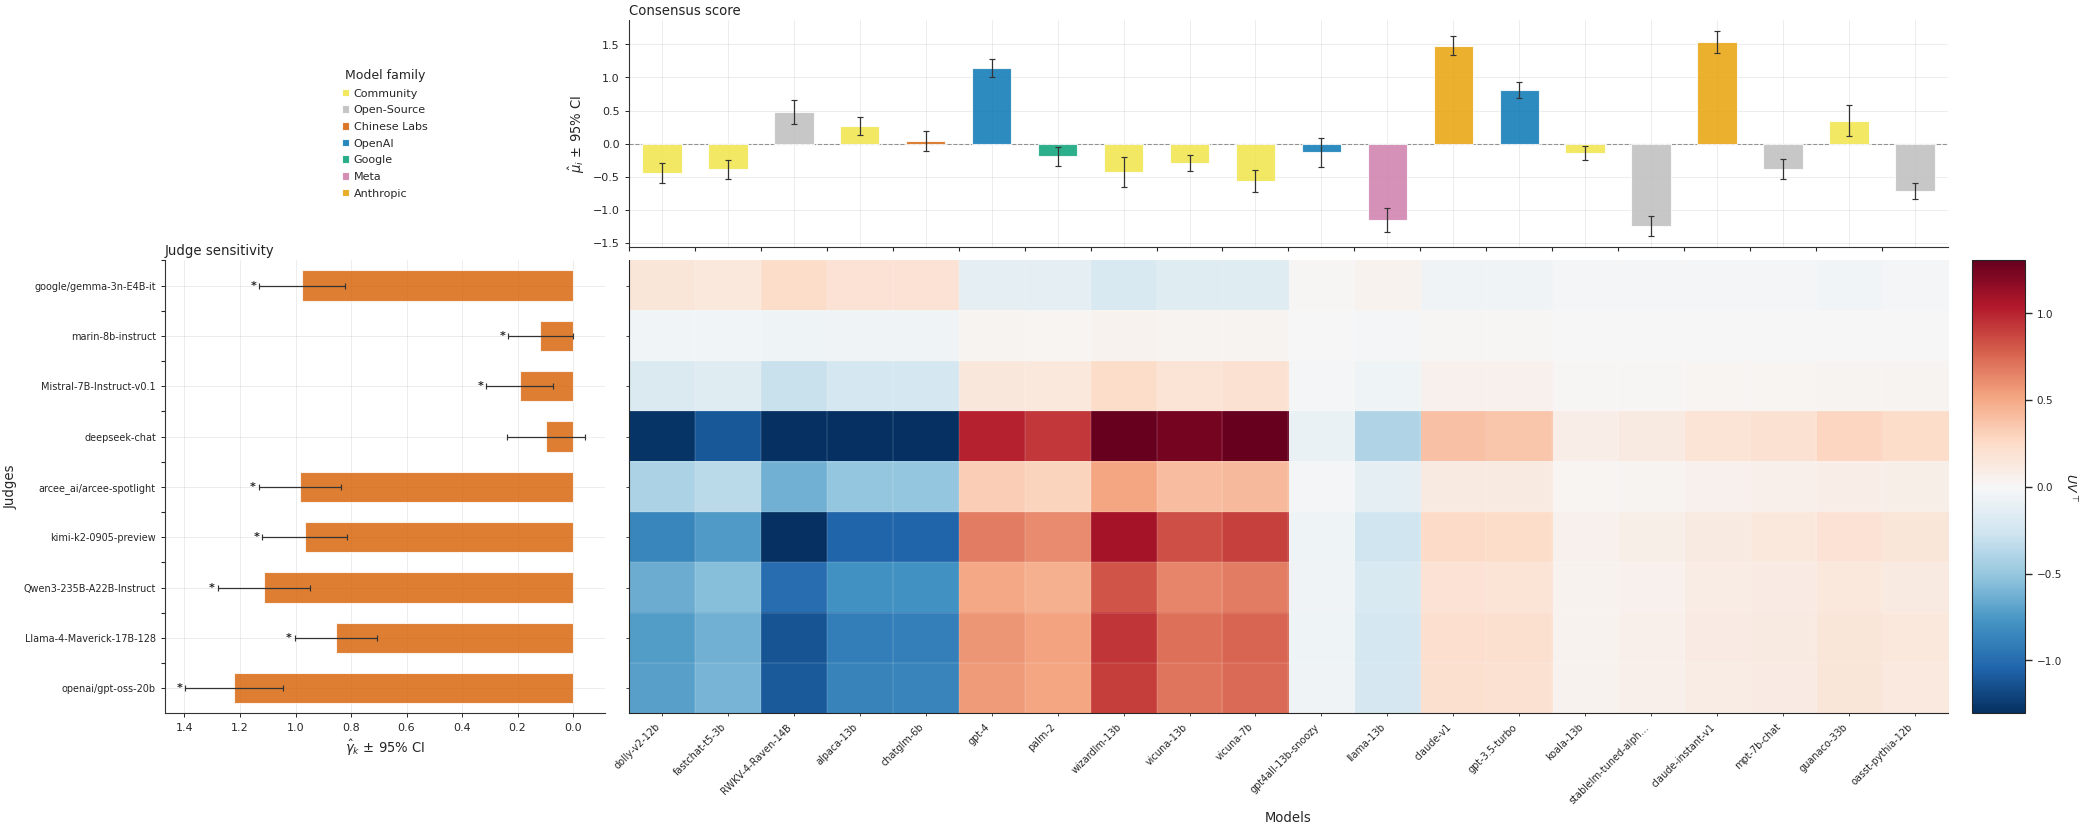

In [130]:
def plot_hja_composite(
    mu_est, gamma_est, U_est, V_est,
    item_names, judge_names,
    mu_half_ci: np.ndarray,
    gamma_half_ci: np.ndarray,
    extreme_judge_name: str = "zai-org/GLM-4.5-Air-FP8",
    figsize: tuple | None = None,
    height_ratios=None,
    width_ratios=None,
    save_pdf=None,
    save_png=None,
):
    """
    2×2 composite figure for HJA real-data analysis.

    Transposed layout (x = models, y = judges) since N > K_f:
    ┌─────────────────┬───────────────────────────────────────────────┐
    │ (a) model-family│ (b) Consensus score μ̂_i ± 95% CI             │
    │     legend      │     vertical bars, x = models cluster-ordered │
    ├─────────────────┼───────────────────────────────────────────────┤
    │ (c) Judge       │ (d) UV^T heatmap                              │
    │     sensitivity │     x = models (cluster-ordered)              │
    │     γ̂_k ± CI   │     y = judges (cluster-ordered)              │
    └─────────────────┴───────────────────────────────────────────────┘

    (b) and (d) share the x-axis (models); (c) and (d) share the y-axis (judges).
    """
    K = len(judge_names)
    N = len(item_names)

    # ── 1. Remove extreme judge ───────────────────────────────────────────────
    if extreme_judge_name in judge_names:
        ext_idx = judge_names.index(extreme_judge_name)
        filt_idx = [i for i in range(K) if i != ext_idx]
    else:
        filt_idx = list(range(K))

    filt_judge_names = [judge_names[i] for i in filt_idx]
    gamma_filt    = gamma_est[filt_idx]
    gamma_ci_filt = gamma_half_ci[filt_idx]
    K_f = len(filt_idx)

    UVT      = U_est @ V_est.T   # (K, N) — judges × models
    UVT_filt = UVT[filt_idx, :]  # (K_f, N)

    # ── 2. Hierarchical clustering ────────────────────────────────────────────
    judge_order = dendrogram(
        linkage(pdist(UVT_filt, metric="euclidean"), method="ward"),
        no_plot=True,
    )["leaves"]
    model_order = dendrogram(
        linkage(pdist(UVT_filt.T, metric="euclidean"), method="ward"),
        no_plot=True,
    )["leaves"]

    # Heatmap: rows = judges (y-axis), cols = models (x-axis)  shape (K_f, N)
    UVT_heat   = UVT_filt[judge_order, :][:, model_order]
    ord_judges = [filt_judge_names[j] for j in judge_order]
    ord_models = [item_names[m]        for m in model_order]

    gamma_ord    = gamma_filt[judge_order]
    gamma_ci_ord = gamma_ci_filt[judge_order]
    mu_ord       = mu_est[model_order]
    mu_ci_ord    = mu_half_ci[model_order]

    # ── 3. Auto-compute layout parameters ──────────────────────────────────────
    if figsize is None:
        if N >= K_f:  # landscape: more models than judges
            figsize = (max(18, N * 1.1), max(8, K_f * 0.55))
        else:         # portrait: more judges than models
            figsize = (max(14, N * 1.8), max(10, K_f * 0.55))
    if height_ratios is None:
        height_ratios = [1, max(2, round(K_f / max(N, 1)))]
    if width_ratios is None:
        if N >= K_f:
            width_ratios = [1, 3, 0.12]
        else:  # more judges: give more width to gamma panel
            width_ratios = [max(1, round(K_f / N)), 1, 0.12]

    # ── 3. Styling ────────────────────────────────────────────────────────────
    apply_presentation_plot_style()

    with plt.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42}):

        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(
            2, 3,
            height_ratios=height_ratios,
            width_ratios=width_ratios,
            hspace=0.04,
            wspace=0.04,
        )
        ax_legend = fig.add_subplot(gs[0, 0])
        ax_mu     = fig.add_subplot(gs[0, 1])                          # top-right
        ax_gamma  = fig.add_subplot(gs[1, 0])                          # bottom-left
        ax_heat   = fig.add_subplot(gs[1, 1], sharex=ax_mu, sharey=ax_gamma)  # bottom-right
        ax_cbar   = fig.add_subplot(gs[1, 2])                          # colorbar column

        x_m = np.arange(N)
        y_j = np.arange(K_f)

        # ── Panel (d): UV^T heatmap  (x = models, y = judges) ────────────────
        vmax = np.percentile(np.abs(UVT_heat), 97)   # robust colour scale
        im = ax_heat.imshow(
            UVT_heat, aspect="auto", cmap="RdBu_r", origin="upper",
            vmin=-vmax, vmax=vmax,
            extent=[-0.5, N - 0.5, K_f - 0.5, -0.5],
        )
        # Cell-boundary grid
        ax_heat.set_xticks(np.arange(N)   - 0.5, minor=True)
        ax_heat.set_yticks(np.arange(K_f) - 0.5, minor=True)
        ax_heat.grid(which="minor", color="white", linewidth=0.25, alpha=0.55)
        ax_heat.tick_params(which="minor", bottom=False, left=False)
        # Major ticks
        ax_heat.set_xticks(x_m)
        ax_heat.set_xticklabels(
            [_shorten(n, 20) for n in ord_models],
            rotation=45, ha="right", fontsize=7.0,
        )
        ax_heat.set_yticks(y_j)
        ax_heat.set_yticklabels(
            [_shorten(n, 24) for n in ord_judges], fontsize=7.0,
        )
        ax_heat.set_xlabel("Models", fontsize=9.5)
        ax_heat.set_ylabel("")
        ax_heat.set_xlim(-0.5, N - 0.5)
        ax_heat.set_ylim(K_f - 0.5, -0.5)
        ax_heat.tick_params(axis="both", length=2.5, width=0.6)
        ax_heat.tick_params(labelleft=False)   # judge names shown on ax_gamma instead
        sns.despine(ax=ax_heat, left=False, bottom=False)

        cbar = fig.colorbar(im, cax=ax_cbar)
        cbar.set_label(r"$UV^\top$", rotation=270, labelpad=12, fontsize=9)
        cbar.ax.tick_params(labelsize=7.5)

        # ── Panel (b): Consensus scores μ  (vertical bars, x = models) ───────
        families      = [_detect_family(n) for n in ord_models]
        bar_colors_mu = [_FAMILY_COLORS.get(f, "#DDDDDD") for f in families]

        ax_mu.bar(x_m, mu_ord, width=0.6, color=bar_colors_mu, alpha=0.82, zorder=3)
        ax_mu.errorbar(
            x_m, mu_ord, yerr=mu_ci_ord,
            fmt="none", ecolor="#333333",
            elinewidth=0.9, capsize=2.5, capthick=0.85, zorder=4,
        )
        ax_mu.axhline(0, color="#555555", linewidth=0.8, linestyle="--", alpha=0.6)
        ax_mu.set_ylabel(r"$\hat{\mu}_i$ ± 95% CI", fontsize=9.5)
        ax_mu.tick_params(labelbottom=False, bottom=False)
        ax_mu.tick_params(axis="y", length=2.5, width=0.6, labelsize=8.0)
        polish_presentation_axis(ax_mu)
        ax_mu.set_title("Consensus score", loc="left",
                        fontsize=9.5, color="#222222", pad=4)

        # ── Panel (c): Judge sensitivity γ  (horizontal bars, y = judges) ────
        bar_colors_gamma = np.where(gamma_ord >= 0, "#D55E00", "#56B4E9")
        ax_gamma.barh(y_j, gamma_ord, height=0.6,
                      color=bar_colors_gamma, alpha=0.80, zorder=3)
        ax_gamma.errorbar(
            gamma_ord, y_j, xerr=gamma_ci_ord,
            fmt="none", ecolor="#333333",
            elinewidth=0.9, capsize=2.5, capthick=0.85, zorder=4,
        )
        # Mark judges whose 95 % CI excludes 0 with *
        sig_mask = (gamma_ord - gamma_ci_ord) > 0
        for yj_pos, gk, ci, sig in zip(y_j, gamma_ord, gamma_ci_ord, sig_mask):
            if sig:
                ax_gamma.text(
                    gk + ci + 0.01, yj_pos, "*",
                    ha="right", va="center",
                    fontsize=8, color="#222222", fontweight="bold",
                )
        ax_gamma.invert_xaxis()   # 0 at right edge (touching heatmap); positive extends left
        ax_gamma.set_xlabel(r"$\hat{\gamma}_k$ ± 95% CI", fontsize=9.5)
        ax_gamma.set_ylabel("Judges", fontsize=9.5)
        ax_gamma.tick_params(axis="y", labelsize=7.0, length=2.5, width=0.6)
        ax_gamma.tick_params(axis="x", length=2.5, width=0.6, labelsize=8.0)
        ax_gamma.set_ylim(K_f - 0.5, -0.5)   # match heatmap y direction (top-down)
        polish_presentation_axis(ax_gamma)
        ax_gamma.set_title("Judge sensitivity", loc="left",
                           fontsize=9.5, color="#222222", pad=4)

        # ── Panel (a): Model-family legend ────────────────────────────────────
        ax_legend.axis("off")
        present_families = dict.fromkeys(families)   # insertion-order dedup
        legend_handles = [
            plt.Rectangle((0, 0), 1, 1,
                           fc=_FAMILY_COLORS.get(f, "#DDDDDD"), alpha=0.85,
                           label=f)
            for f in present_families
        ]
        ax_legend.legend(
            handles=legend_handles,
            loc="center",
            frameon=False,
            title="Model family",
            title_fontsize=9,
            fontsize=8.0,
            handlelength=0.6,
            labelspacing=0.6,
            ncol=1,
            handletextpad=0.4,
        )
        # fig.suptitle(
        #     "ChatBot Arena — HJA decomposition  "
        #     r"($\hat{\mu}$, $\hat{\gamma}$, $UV^\top$)",
        #     fontsize=11, y=1.003, color="#222222",
        # )

        if save_pdf is not None:
            fig.savefig(save_pdf, dpi=300, bbox_inches="tight")
        if save_png is not None:
            fig.savefig(save_png, dpi=150, bbox_inches="tight")
        plt.show()

    return fig


# ── Generate figure ───────────────────────────────────────────────────────────
composite_pdf = OUTPUT_DIR / "paper_ready_chatbot_arena_composite.pdf"
composite_png = OUTPUT_DIR / "paper_ready_chatbot_arena_composite.png"

fig_composite = plot_hja_composite(
    mu_est, gamma_est, U_est, V_est,
    item_names, judge_names,
    mu_half_ci_arr, gamma_half_ci_arr,
    extreme_judge_name="zai-org/GLM-4.5-Air-FP8",
    figsize=(24, 9),
    save_pdf=composite_pdf,
    save_png=composite_png,
)

In [131]:
## ── Analytical insights summary ──────────────────────────────────────────────
print("=" * 68)
print("CHATBOT ARENA — HJA ANALYTICAL INSIGHTS")
print("=" * 68)

# ── 1. Consensus ranking with tier structure ──────────────────────────────────
sorted_idx   = np.argsort(mu_est)[::-1]
mu_sorted    = mu_est[sorted_idx]
ci_sorted    = mu_half_ci_arr[sorted_idx]
names_sorted = [item_names[i] for i in sorted_idx]

print("\n[1] TOP-10 MODELS  (consensus score ± 95% CI)")
print(f"{'Rank':>4}  {'Model':<40}  {'μ̂':>8}  {'±CI':>7}")
print("-" * 64)
for rank, (name, mu_v, ci_v) in enumerate(zip(names_sorted, mu_sorted, ci_sorted), 1):
    if rank > 10:
        break
    print(f"{rank:>4}  {_shorten(name, 40):<40}  {mu_v:>8.4f}  {ci_v:>7.4f}")

# ── 2. Model tiers (overlapping-CI groups) ────────────────────────────────────
tiers, current_tier = [], [0]
for j in range(1, N):
    # New tier if lower bound of current model is above upper bound of prev group top
    prev_lower = mu_sorted[current_tier[0]] - ci_sorted[current_tier[0]]
    this_upper = mu_sorted[j] + ci_sorted[j]
    if this_upper < prev_lower:
        tiers.append(current_tier)
        current_tier = [j]
    else:
        current_tier.append(j)
tiers.append(current_tier)

print(f"\n[2] TIER STRUCTURE  ({len(tiers)} tiers by non-overlapping 95% CIs)")
for t_idx, tier in enumerate(tiers[:6], 1):
    tier_names = [_shorten(names_sorted[i], 28) for i in tier]
    score_range = f"{mu_sorted[tier[-1]]:.3f} – {mu_sorted[tier[0]]:.3f}"
    print(f"  Tier {t_idx} ({score_range}):  {', '.join(tier_names)}")
if len(tiers) > 6:
    print(f"  ... ({len(tiers) - 6} more tiers)")

# ── 3. Judge sensitivity analysis ─────────────────────────────────────────────
# Use filtered judge list (same as composite plot, excluding extreme judge)
extreme_judge_name = "zai-org/GLM-4.5-Air-FP8"
filt_idx_analysis = [i for i in range(K) if judge_names[i] != extreme_judge_name]
filt_jnames   = [judge_names[i] for i in filt_idx_analysis]
gamma_filt_a  = gamma_est[filt_idx_analysis]
gamma_ci_filt_a = gamma_half_ci_arr[filt_idx_analysis]

sig_high  = [(j, g, c) for j, g, c in zip(filt_jnames, gamma_filt_a, gamma_ci_filt_a) if (g - c) > 0]
sig_low   = [(j, g, c) for j, g, c in zip(filt_jnames, gamma_filt_a, gamma_ci_filt_a) if (g + c) < 0]
uncertain = [(j, g, c) for j, g, c in zip(filt_jnames, gamma_filt_a, gamma_ci_filt_a) if (g - c) <= 0 <= (g + c)]

print(f"\n[3] JUDGE SENSITIVITY  (γ̂ with 95% CI, excluding {extreme_judge_name})")
print(f"  Significantly discriminative (γ > 0): {len(sig_high)}/{len(filt_idx_analysis)}")
print(f"  Significantly contrarian   (γ < 0): {len(sig_low)}/{len(filt_idx_analysis)}")
print(f"  CI includes 0 (uncertain):            {len(uncertain)}/{len(filt_idx_analysis)}")
if sig_high:
    top_judges = sorted(sig_high, key=lambda x: -x[1])[:5]
    print("  Top-5 most discriminative judges:")
    for jname, gv, cv in top_judges:
        print(f"    {_shorten(jname, 40):<40}  γ̂={gv:+.4f}  ±{cv:.4f}")
if sig_low:
    print("  Contrarian judges (γ < 0):")
    for jname, gv, cv in sorted(sig_low, key=lambda x: x[1])[:3]:
        print(f"    {_shorten(jname, 40):<40}  γ̂={gv:+.4f}  ±{cv:.4f}")

# ── 4. UV^T heterogeneity summary ─────────────────────────────────────────────
UVT_analysis = (U_est @ V_est.T)[filt_idx_analysis, :]
row_std = UVT_analysis.std(axis=1)   # per-judge variation across models
col_std = UVT_analysis.std(axis=0)   # per-model variation across judges

top_het_judge_idx = np.argsort(row_std)[::-1][:5]
top_het_model_idx = np.argsort(col_std)[::-1][:5]

print(f"\n[4] UV^T HETEROGENEITY  (std of interaction profile)")
print("  Judges with most heterogeneous model preferences:")
for i in top_het_judge_idx:
    print(f"    {_shorten(filt_jnames[i], 40):<40}  row-std={row_std[i]:.4f}")
print("  Models with most divergent judge opinions:")
for i in top_het_model_idx:
    print(f"    {_shorten(item_names[i], 40):<40}  col-std={col_std[i]:.4f}")

# ── 5. Extreme judge note ─────────────────────────────────────────────────────
if extreme_judge_name in judge_names:
    ext_i = judge_names.index(extreme_judge_name)
    print(f"\n[5] EXCLUDED JUDGE  '{extreme_judge_name}'")
    print(f"    γ̂ = {gamma_est[ext_i]:.4f}  ±{gamma_half_ci_arr[ext_i]:.4f}")
    print(f"    UV^T row std = {(U_est @ V_est.T)[ext_i, :].std():.4f}")
    print("    Excluded from panels (b) and (d) due to extreme scale dominating colorbar.")

print("\n" + "=" * 68)


CHATBOT ARENA — HJA ANALYTICAL INSIGHTS

[1] TOP-10 MODELS  (consensus score ± 95% CI)
Rank  Model                                           μ̂      ±CI
----------------------------------------------------------------
   1  claude-instant-v1                           1.5421   0.1671
   2  claude-v1                                   1.4800   0.1434
   3  gpt-4                                       1.1475   0.1345
   4  gpt-3.5-turbo                               0.8104   0.1220
   5  RWKV-4-Raven-14B                            0.4759   0.1771
   6  guanaco-33b                                 0.3481   0.2344
   7  alpaca-13b                                  0.2686   0.1380
   8  chatglm-6b                                  0.0394   0.1491
   9  gpt4all-13b-snoozy                         -0.1324   0.2217
  10  koala-13b                                  -0.1431   0.1098

[2] TIER STRUCTURE  (8 tiers by non-overlapping 95% CIs)
  Tier 1 (1.480 – 1.542):  claude-instant-v1, claude-v1
  Tier 2

## MT-Bench Analysis

In [132]:
# Load MT-Bench dataset
print("Loading MT-Bench dataset...")
MTBENCH_PATH = EXPERIMENTS_DIR / "data" / "judge_results_10k_mtbench.json"
dataset_mtbench = load_real_dataset(str(MTBENCH_PATH))

summary_mtbench = dataset_mtbench["summary"]
processed_records_mtbench = dataset_mtbench["processed"]
item_names_mtbench = dataset_mtbench["item_names"]
judge_names_mtbench = dataset_mtbench["judge_names"]
N_mtbench = len(item_names_mtbench)
K_mtbench = len(judge_names_mtbench)

print(f"\nDataset Summary:")
print(f"  Total raw records: {summary_mtbench['total_records']}")
print(f"  Usable records: {summary_mtbench['usable_records']}")
print(f"  Number of judges (K): {K_mtbench}")
print(f"  Number of items (N): {N_mtbench}")

# Convert to aggregated format
n_ijk_mtbench, y_ijk_mtbench = processed_records_to_aggregated(processed_records_mtbench, N_mtbench, K_mtbench)

# Use rank 1 (from prior analysis)
r_model_mtbench = 1
print(f"\nFitting proposed method with rank r={r_model_mtbench}...")
fit_proposed_mtbench = fit_proposed(N_mtbench, K_mtbench, r_model_mtbench, n_ijk_mtbench, y_ijk_mtbench, 
                                     max_steps=40, tol=5e-5, tau=30.0)

mu_est_mtbench = fit_proposed_mtbench["mu"]
gamma_est_mtbench = fit_proposed_mtbench["gamma"]
U_est_mtbench = fit_proposed_mtbench["U"]
V_est_mtbench = fit_proposed_mtbench["V"]

# Compute confidence intervals
print(f"\nComputing confidence intervals for model scores (alpha=0.05)...")
targets_mtbench = [{"type": "consensus_score", "i": i, "label": f"mu[{i}]"} for i in range(N_mtbench)]
uq_results_mtbench = uncertainty_quantification(gamma_est_mtbench, mu_est_mtbench, U_est_mtbench, V_est_mtbench, 
                                                 n_ijk_mtbench, targets_mtbench, alpha=0.05)

half_ci_by_label_mtbench = {}
for interval in uq_results_mtbench["intervals"]:
    label = interval["label"]
    half_ci_by_label_mtbench[label] = 0.5 * (interval["upper"] - interval["lower"])

# Create ranking table
ranking_data_mtbench = []
for idx, model in enumerate(item_names_mtbench):
    score = mu_est_mtbench[idx]
    half_ci = half_ci_by_label_mtbench.get(f"mu[{idx}]", 0.0)
    ranking_data_mtbench.append({
        "Model": model,
        "Score": f"${score:.4f} \\pm {half_ci:.4f}$",
        "Score value": score,
        "Half CI": half_ci,
    })

ranking_df_mtbench = pd.DataFrame(ranking_data_mtbench)
ranking_df_mtbench = ranking_df_mtbench.sort_values("Score value", ascending=False).reset_index(drop=True)
ranking_df_mtbench["Rank"] = range(1, len(ranking_df_mtbench) + 1)
ranking_df_mtbench = ranking_df_mtbench[["Rank", "Model", "Score"]]

print("\nModel Rankings with 95% Confidence Intervals (from MT-Bench):")
print(ranking_df_mtbench.to_string(index=False))

# Judge gamma table
gamma_targets_mtbench = [{"type": "gamma", "k": k, "label": f"gamma[{k}]"} for k in range(K_mtbench)]
gamma_uq_results_mtbench = uncertainty_quantification(gamma_est_mtbench, mu_est_mtbench, U_est_mtbench, V_est_mtbench, 
                                                       n_ijk_mtbench, gamma_targets_mtbench, alpha=0.05)

gamma_half_ci_by_label_mtbench = {}
for interval in gamma_uq_results_mtbench["intervals"]:
    label = interval["label"]
    gamma_half_ci_by_label_mtbench[label] = 0.5 * (interval["upper"] - interval["lower"])

gamma_data_mtbench = []
for idx, judge in enumerate(judge_names_mtbench):
    gamma = gamma_est_mtbench[idx]
    half_ci = gamma_half_ci_by_label_mtbench.get(f"gamma[{idx}]", 0.0)
    gamma_data_mtbench.append({
        "Judge": judge,
        "Gamma": f"${gamma:.4f} \\pm {half_ci:.4f}$",
        "Gamma value": gamma,
        "Half CI": half_ci,
    })

gamma_df_mtbench = pd.DataFrame(gamma_data_mtbench)
gamma_df_mtbench = gamma_df_mtbench.sort_values("Gamma value", ascending=False).reset_index(drop=True)
gamma_df_mtbench = gamma_df_mtbench[["Judge", "Gamma"]]

print("\nJudge-specific parameters (gamma) - MT-Bench:")
print(gamma_df_mtbench.to_string(index=False))

Loading MT-Bench dataset...

Dataset Summary:
  Total raw records: 10000
  Usable records: 9706
  Number of judges (K): 20
  Number of items (N): 6

Fitting proposed method with rank r=1...

Computing confidence intervals for model scores (alpha=0.05)...

Model Rankings with 95% Confidence Intervals (from MT-Bench):
 Rank           Model                Score
    1       claude-v1  $1.1652 \pm 0.0806$
    2           gpt-4  $0.9334 \pm 0.0728$
    3   gpt-3.5-turbo  $0.6311 \pm 0.0660$
    4      alpaca-13b $-0.4882 \pm 0.0899$
    5 vicuna-13b-v1.2 $-0.5914 \pm 0.0863$
    6       llama-13b $-1.6501 \pm 0.0864$

Judge-specific parameters (gamma) - MT-Bench:
                                            Judge                Gamma
                          zai-org/GLM-4.5-Air-FP8  $1.9371 \pm 0.2006$
                 Qwen/Qwen3-Next-80B-A3B-Instruct  $1.3627 \pm 0.2220$
                                  moonshot-v1-32k  $1.2989 \pm 0.2071$
                             kimi-k2-0905-preview 

UV^T shape: (20, 6)
UV^T min: -5.6682, max: 8.2208



Wrote MT-Bench UV^T heatmap to: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_mtbench_uvt_heatmap.pdf


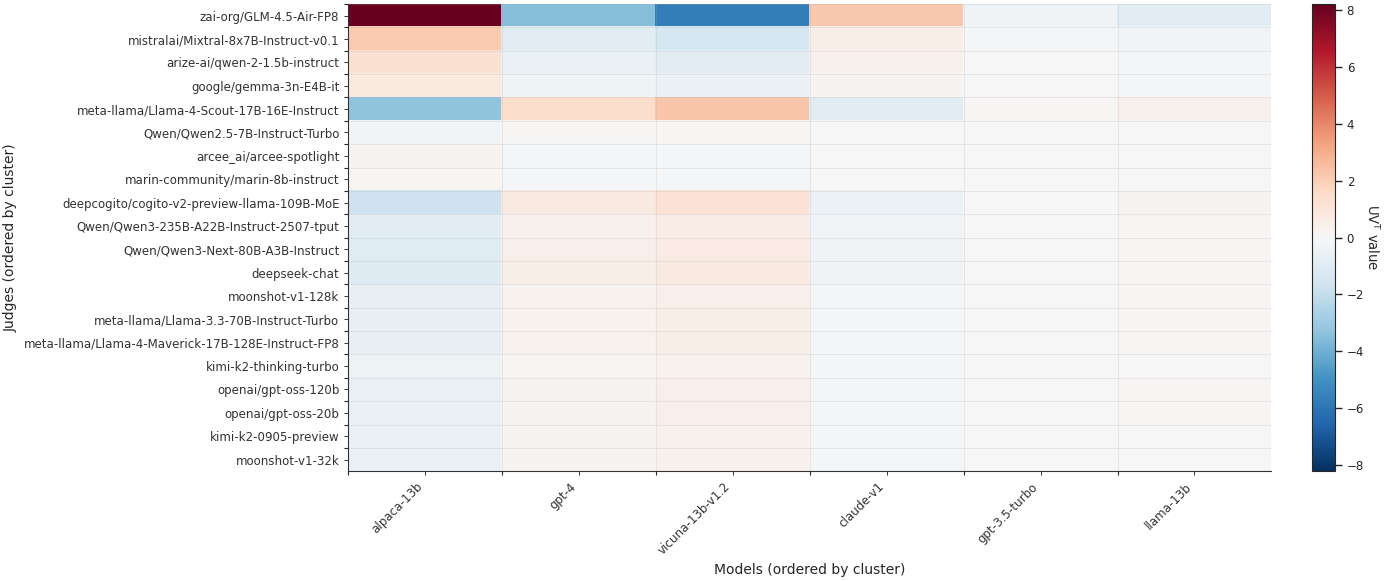

In [133]:
# UV^T heatmap for MT-Bench
UVT_mtbench = U_est_mtbench @ V_est_mtbench.T
print(f"UV^T shape: {UVT_mtbench.shape}")
print(f"UV^T min: {np.min(UVT_mtbench):.4f}, max: {np.max(UVT_mtbench):.4f}")

# Apply hierarchical clustering
judge_distances_mtbench = pdist(UVT_mtbench, metric='euclidean')
judge_linkage_mtbench = linkage(judge_distances_mtbench, method='ward')
judge_order_mtbench = dendrogram(judge_linkage_mtbench, no_plot=True)['leaves']

model_distances_mtbench = pdist(UVT_mtbench.T, metric='euclidean')
model_linkage_mtbench = linkage(model_distances_mtbench, method='ward')
model_order_mtbench = dendrogram(model_linkage_mtbench, no_plot=True)['leaves']

# Reorder
UVT_clustered_mtbench = UVT_mtbench[judge_order_mtbench, :][:, model_order_mtbench]
clustered_judge_names_mtbench = [judge_names_mtbench[i] for i in judge_order_mtbench]
clustered_model_names_mtbench = [item_names_mtbench[i] for i in model_order_mtbench]

# Create heatmap
sns.set_theme(
    style="ticks",
    context="paper",
    font="DejaVu Sans",
    rc={
        "font.size": 9.0,
        "axes.labelsize": 10.0,
        "axes.titlesize": 11.0,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    },
)

fig, ax = plt.subplots(figsize=(14, 6))
vmax_mtbench = np.max(np.abs(UVT_clustered_mtbench))
vmin_mtbench = -vmax_mtbench

im = ax.imshow(UVT_clustered_mtbench, aspect='auto', cmap='RdBu_r', origin='upper',
               vmin=vmin_mtbench, vmax=vmax_mtbench)

ax.set_xticks(np.arange(len(clustered_model_names_mtbench)))
ax.set_yticks(np.arange(len(clustered_judge_names_mtbench)))
ax.set_xticklabels(clustered_model_names_mtbench, rotation=45, ha='right', fontsize=8.5)
ax.set_yticklabels(clustered_judge_names_mtbench, fontsize=8.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('UV$^\\mathrm{T}$ value', rotation=270, labelpad=12, fontsize=9.5)

ax.set_xlabel('Models (ordered by cluster)', fontsize=10)
ax.set_ylabel('Judges (ordered by cluster)', fontsize=10)

sns.despine(ax=ax, left=False, bottom=False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', length=3, width=0.7, colors='#333333')

ax.set_xticks(np.arange(len(clustered_model_names_mtbench))-.5, minor=True)
ax.set_yticks(np.arange(len(clustered_judge_names_mtbench))-.5, minor=True)
ax.grid(which='minor', color='#B0B0B0', linestyle='-', linewidth=0.45, alpha=0.35)
ax.set_axisbelow(True)

fig.tight_layout()

uvt_output_path_mtbench = OUTPUT_DIR / "paper_ready_mtbench_uvt_heatmap.pdf"
fig.savefig(uvt_output_path_mtbench, dpi=300, bbox_inches='tight')
print(f"\nWrote MT-Bench UV^T heatmap to: {uvt_output_path_mtbench}")

plt.show()

In [134]:
# ── MT-Bench: flatten CI dictionaries into ordered arrays ──────────────────
mu_half_ci_arr_mtbench = np.array(
    [half_ci_by_label_mtbench.get(f"mu[{i}]", 0.0) for i in range(N_mtbench)]
)
gamma_half_ci_arr_mtbench = np.array(
    [gamma_half_ci_by_label_mtbench.get(f"gamma[{k}]", 0.0) for k in range(K_mtbench)]
)

print(f"MT-Bench  mu    half-CI: min={mu_half_ci_arr_mtbench.min():.4f}  max={mu_half_ci_arr_mtbench.max():.4f}")
print(f"MT-Bench  gamma half-CI: min={gamma_half_ci_arr_mtbench.min():.4f}  max={gamma_half_ci_arr_mtbench.max():.4f}")
print(f"MT-Bench  mu    range  : [{mu_est_mtbench.min():.4f}, {mu_est_mtbench.max():.4f}]")
print(f"MT-Bench  gamma range  : [{gamma_est_mtbench.min():.4f}, {gamma_est_mtbench.max():.4f}]")


MT-Bench  mu    half-CI: min=0.0660  max=0.0899
MT-Bench  gamma half-CI: min=0.1160  max=0.2376
MT-Bench  mu    range  : [-1.6501, 1.1652]
MT-Bench  gamma range  : [-0.0669, 1.9371]


### MT-Bench Composite Figure

MT-Bench has **K > N** (20 judges, 6 models after fitting), so the heatmap is tall and narrow.
The auto-layout logic adjusts `height_ratios` and `width_ratios` accordingly.


MT-Bench model → family:
  alpaca-13b                                →  Community
  claude-v1                                 →  Anthropic
  gpt-3.5-turbo                             →  OpenAI
  gpt-4                                     →  OpenAI
  llama-13b                                 →  Meta
  vicuna-13b-v1.2                           →  Community


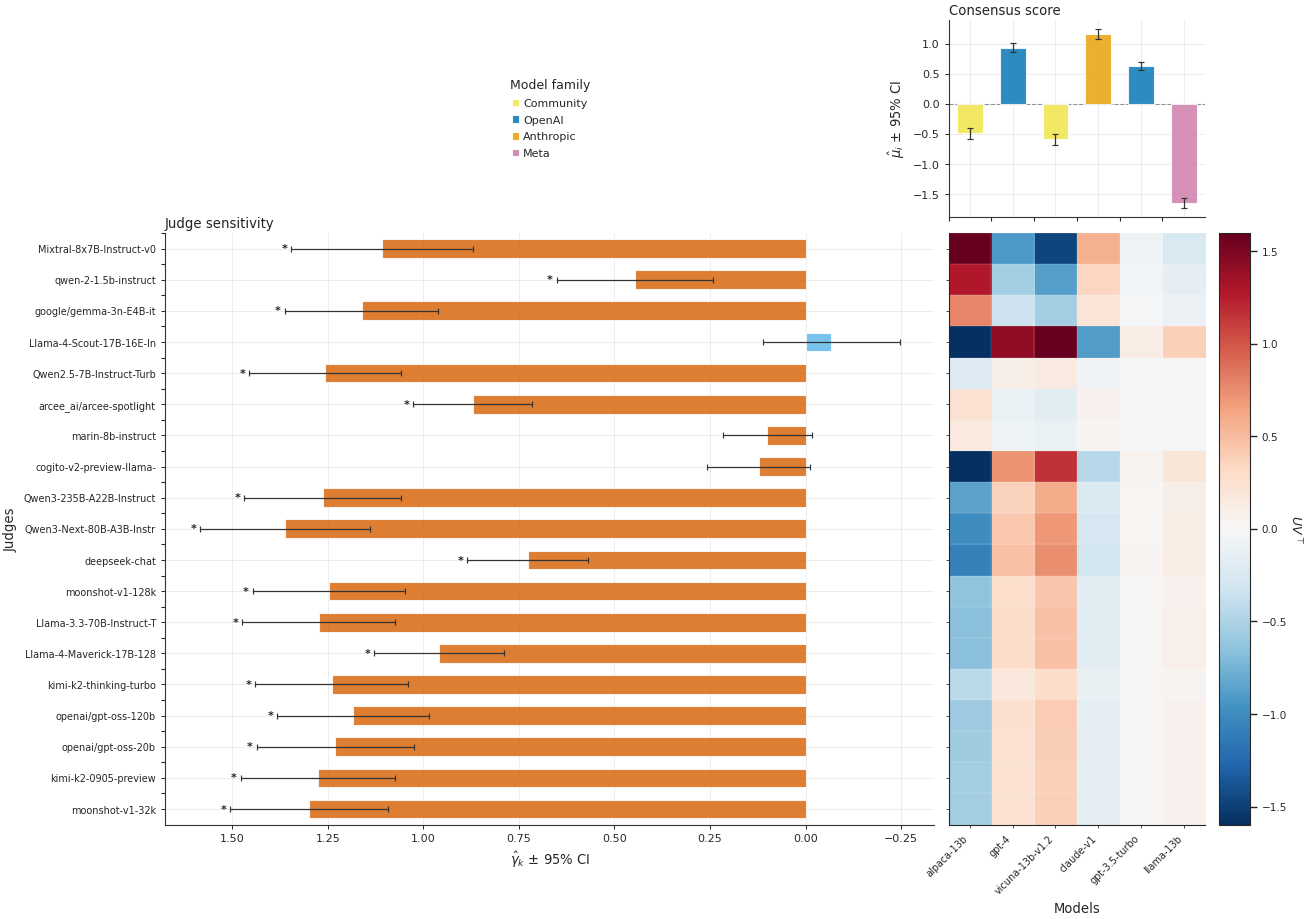

In [135]:
# Sanity-check: family assignment for MT-Bench models
print("MT-Bench model → family:")
for mn in sorted(item_names_mtbench):
    print(f"  {mn:<40}  →  {_detect_family(mn)}")

mtbench_pdf = OUTPUT_DIR / "paper_ready_mtbench_composite.pdf"
mtbench_png = OUTPUT_DIR / "paper_ready_mtbench_composite.png"

fig_mtbench = plot_hja_composite(
    mu_est_mtbench, gamma_est_mtbench, U_est_mtbench, V_est_mtbench,
    item_names_mtbench, judge_names_mtbench,
    mu_half_ci_arr_mtbench, gamma_half_ci_arr_mtbench,
    extreme_judge_name="zai-org/GLM-4.5-Air-FP8",
    save_pdf=mtbench_pdf,
    save_png=mtbench_png,
)


In [136]:
## ── MT-Bench: Analytical insights ──────────────────────────────────────────
print("=" * 68)
print("MT-BENCH — HJA ANALYTICAL INSIGHTS")
print("=" * 68)

sorted_idx_mt   = np.argsort(mu_est_mtbench)[::-1]
mu_sorted_mt    = mu_est_mtbench[sorted_idx_mt]
ci_sorted_mt    = mu_half_ci_arr_mtbench[sorted_idx_mt]
names_sorted_mt = [item_names_mtbench[i] for i in sorted_idx_mt]

print("\n[1] MODEL RANKING  (consensus score ± 95% CI)")
print(f"  {'Rank':>4}  {'Model':<40}  {'μ̂':>8}  {'±CI':>7}")
print("  " + "-" * 62)
for rank, (name, mu_v, ci_v) in enumerate(zip(names_sorted_mt, mu_sorted_mt, ci_sorted_mt), 1):
    print(f"  {rank:>4}  {_shorten(name, 40):<40}  {mu_v:>8.4f}  {ci_v:>7.4f}")

# Tiers
N_mt = len(item_names_mtbench)
tiers_mt, current_tier_mt = [], [0]
for j in range(1, N_mt):
    prev_lower = mu_sorted_mt[current_tier_mt[0]] - ci_sorted_mt[current_tier_mt[0]]
    this_upper = mu_sorted_mt[j] + ci_sorted_mt[j]
    if this_upper < prev_lower:
        tiers_mt.append(current_tier_mt)
        current_tier_mt = [j]
    else:
        current_tier_mt.append(j)
tiers_mt.append(current_tier_mt)

print(f"\n[2] TIER STRUCTURE  ({len(tiers_mt)} tiers by non-overlapping 95% CIs)")
for t_idx, tier in enumerate(tiers_mt, 1):
    tier_names = [_shorten(names_sorted_mt[i], 28) for i in tier]
    score_range = f"{mu_sorted_mt[tier[-1]]:.3f} – {mu_sorted_mt[tier[0]]:.3f}"
    print(f"  Tier {t_idx} ({score_range}):  {', '.join(tier_names)}")

# Judge sensitivity
extreme_judge_name_mt = "zai-org/GLM-4.5-Air-FP8"
filt_idx_mt = [i for i in range(K_mtbench) if judge_names_mtbench[i] != extreme_judge_name_mt]
filt_jnames_mt   = [judge_names_mtbench[i] for i in filt_idx_mt]
gamma_filt_mt    = gamma_est_mtbench[filt_idx_mt]
gamma_ci_filt_mt = gamma_half_ci_arr_mtbench[filt_idx_mt]

sig_high_mt  = [(j, g, c) for j, g, c in zip(filt_jnames_mt, gamma_filt_mt, gamma_ci_filt_mt) if (g - c) > 0]
sig_low_mt   = [(j, g, c) for j, g, c in zip(filt_jnames_mt, gamma_filt_mt, gamma_ci_filt_mt) if (g + c) < 0]
uncertain_mt = [(j, g, c) for j, g, c in zip(filt_jnames_mt, gamma_filt_mt, gamma_ci_filt_mt) if (g - c) <= 0 <= (g + c)]

print(f"\n[3] JUDGE SENSITIVITY  (γ̂ with 95% CI, excluding {extreme_judge_name_mt})")
print(f"  Significantly discriminative (γ > 0): {len(sig_high_mt)}/{len(filt_idx_mt)}")
print(f"  Significantly contrarian   (γ < 0): {len(sig_low_mt)}/{len(filt_idx_mt)}")
print(f"  CI includes 0 (uncertain):            {len(uncertain_mt)}/{len(filt_idx_mt)}")
if sig_high_mt:
    top_judges_mt = sorted(sig_high_mt, key=lambda x: -x[1])[:5]
    print("  Top-5 most discriminative judges:")
    for jname, gv, cv in top_judges_mt:
        print(f"    {_shorten(jname, 40):<40}  γ̂={gv:+.4f}  ±{cv:.4f}")
if sig_low_mt:
    print("  Contrarian judges (γ < 0):")
    for jname, gv, cv in sorted(sig_low_mt, key=lambda x: x[1])[:3]:
        print(f"    {_shorten(jname, 40):<40}  γ̂={gv:+.4f}  ±{cv:.4f}")

# UV^T heterogeneity
UVT_mt = (U_est_mtbench @ V_est_mtbench.T)[filt_idx_mt, :]
row_std_mt = UVT_mt.std(axis=1)
col_std_mt = UVT_mt.std(axis=0)

print(f"\n[4] UV^T HETEROGENEITY")
print("  Judges with most heterogeneous model preferences:")
for i in np.argsort(row_std_mt)[::-1][:5]:
    print(f"    {_shorten(filt_jnames_mt[i], 40):<40}  row-std={row_std_mt[i]:.4f}")
print("  Models with most divergent judge opinions:")
for i in np.argsort(col_std_mt)[::-1][:N_mt]:
    print(f"    {_shorten(item_names_mtbench[i], 40):<40}  col-std={col_std_mt[i]:.4f}")

print("\n" + "=" * 68)


MT-BENCH — HJA ANALYTICAL INSIGHTS

[1] MODEL RANKING  (consensus score ± 95% CI)
  Rank  Model                                           μ̂      ±CI
  --------------------------------------------------------------
     1  claude-v1                                   1.1652   0.0806
     2  gpt-4                                       0.9334   0.0728
     3  gpt-3.5-turbo                               0.6311   0.0660
     4  alpaca-13b                                 -0.4882   0.0899
     5  vicuna-13b-v1.2                            -0.5914   0.0863
     6  llama-13b                                  -1.6501   0.0864

[2] TIER STRUCTURE  (5 tiers by non-overlapping 95% CIs)
  Tier 1 (1.165 – 1.165):  claude-v1
  Tier 2 (0.933 – 0.933):  gpt-4
  Tier 3 (0.631 – 0.631):  gpt-3.5-turbo
  Tier 4 (-0.591 – -0.488):  alpaca-13b, vicuna-13b-v1.2
  Tier 5 (-1.650 – -1.650):  llama-13b

[3] JUDGE SENSITIVITY  (γ̂ with 95% CI, excluding zai-org/GLM-4.5-Air-FP8)
  Significantly discriminative (γ > 

## UltraFeedback Analysis

In [137]:
# Load UltraFeedback dataset
print("Loading UltraFeedback dataset...")
ultrafeedback_path = EXPERIMENTS_DIR / "data" / "judge_results_10k_ultrafeedback.json"
dataset_ultrafeedback = load_real_dataset(str(ultrafeedback_path))

summary_ultrafeedback = dataset_ultrafeedback["summary"]
processed_records_ultrafeedback = dataset_ultrafeedback["processed"]
item_names_ultrafeedback = dataset_ultrafeedback["item_names"]
judge_names_ultrafeedback = dataset_ultrafeedback["judge_names"]
N_ultrafeedback = len(item_names_ultrafeedback)
K_ultrafeedback = len(judge_names_ultrafeedback)

print(f"UltraFeedback: N={N_ultrafeedback}, K={K_ultrafeedback}")
print(f"  Total raw records: {summary_ultrafeedback['total_records']}")
print(f"  Usable records: {summary_ultrafeedback['usable_records']}")
print(f"  Unknown labels skipped: {summary_ultrafeedback['unknown_count']}")
print(f"  Tie labels kept: {summary_ultrafeedback['tie_count']}")

n_ijk_ultrafeedback, y_ijk_ultrafeedback = processed_records_to_aggregated(
    processed_records_ultrafeedback, N_ultrafeedback, K_ultrafeedback
)

# Fit HJA model
fit_result_ultrafeedback = fit_proposed(
    N_ultrafeedback, K_ultrafeedback, r_model=1,
    n_ijk=n_ijk_ultrafeedback, y_ijk=y_ijk_ultrafeedback,
    max_steps=40, tol=5e-5, tau=5
)

mu_est_ultrafeedback = fit_result_ultrafeedback["mu"]
gamma_est_ultrafeedback = fit_result_ultrafeedback["gamma"]
U_est_ultrafeedback = fit_result_ultrafeedback["U"]
V_est_ultrafeedback = fit_result_ultrafeedback["V"]

# Compute UQ for mu (consensus_score targets)
targets_mu_ultrafeedback = [
    {"type": "consensus_score", "i": i, "label": f"mu[{i}]"}
    for i in range(N_ultrafeedback)
]
uq_results_mu_ultrafeedback = uncertainty_quantification(
    gamma_est_ultrafeedback, mu_est_ultrafeedback, U_est_ultrafeedback, V_est_ultrafeedback,
    n_ijk_ultrafeedback, targets_mu_ultrafeedback, alpha=0.05
)
intervals_mu_ultrafeedback = {
    interval["label"]: interval for interval in uq_results_mu_ultrafeedback["intervals"]
}

# Compute UQ for gamma targets
targets_gamma_ultrafeedback = [
    {"type": "gamma", "k": k, "label": f"gamma[{k}]"}
    for k in range(K_ultrafeedback)
]
uq_results_gamma_ultrafeedback = uncertainty_quantification(
    gamma_est_ultrafeedback, mu_est_ultrafeedback, U_est_ultrafeedback, V_est_ultrafeedback,
    n_ijk_ultrafeedback, targets_gamma_ultrafeedback, alpha=0.05
)
intervals_gamma_ultrafeedback = {
    interval["label"]: interval for interval in uq_results_gamma_ultrafeedback["intervals"]
}

# Create ranking dataframe for UltraFeedback
ranking_data_ultrafeedback = []
for i, item_name in enumerate(item_names_ultrafeedback):
    score = mu_est_ultrafeedback[i]
    interval = intervals_mu_ultrafeedback[f"mu[{i}]"]
    half_ci = 0.5 * (interval["upper"] - interval["lower"])
    ranking_data_ultrafeedback.append({
        "Model": item_name,
        "Score": f"${score:.4f} \\pm {half_ci:.4f}$",
        "score_numeric": score
    })

ranking_df_ultrafeedback = pd.DataFrame(ranking_data_ultrafeedback).sort_values('score_numeric', ascending=False)
ranking_df_ultrafeedback['Rank'] = range(1, len(ranking_df_ultrafeedback) + 1)
ranking_df_ultrafeedback = ranking_df_ultrafeedback[['Rank', 'Model', 'Score']].reset_index(drop=True)

print("\n=== UltraFeedback Model Rankings ===")
print(ranking_df_ultrafeedback.to_string(index=False))

# Create gamma dataframe for UltraFeedback
gamma_data_ultrafeedback = []
for k, judge_name in enumerate(judge_names_ultrafeedback):
    gamma = gamma_est_ultrafeedback[k]
    interval = intervals_gamma_ultrafeedback[f"gamma[{k}]"]
    half_ci = 0.5 * (interval["upper"] - interval["lower"])
    gamma_data_ultrafeedback.append({
        "Judge": judge_name,
        "Gamma": f"${gamma:.4f} \\pm {half_ci:.4f}$",
        "gamma_numeric": gamma
    })

gamma_df_ultrafeedback = pd.DataFrame(gamma_data_ultrafeedback).sort_values('gamma_numeric', ascending=False)
gamma_df_ultrafeedback = gamma_df_ultrafeedback[['Judge', 'Gamma']].reset_index(drop=True)

print("\n=== UltraFeedback Judge Reliability (gamma) ===")
print(gamma_df_ultrafeedback.to_string(index=False))


Loading UltraFeedback dataset...
UltraFeedback: N=17, K=20
  Total raw records: 10000
  Usable records: 9726
  Unknown labels skipped: 274
  Tie labels kept: 761



=== UltraFeedback Model Rankings ===
 Rank               Model                Score
    1       gpt-3.5-turbo  $1.4626 \pm 0.1342$
    2               gpt-4  $1.3863 \pm 0.1318$
    3                bard  $0.5079 \pm 0.1697$
    4    llama-2-70b-chat  $0.3452 \pm 0.1179$
    5        mpt-30b-chat  $0.2206 \pm 0.1129$
    6        wizardlm-70b  $0.2075 \pm 0.1325$
    7    llama-2-13b-chat  $0.2070 \pm 0.1124$
    8          vicuna-33b  $0.1347 \pm 0.1225$
    9        wizardlm-13b  $0.0606 \pm 0.1276$
   10         ultralm-13b $-0.2326 \pm 0.1173$
   11         ultralm-65b $-0.2462 \pm 0.1229$
   12     llama-2-7b-chat $-0.2480 \pm 0.1173$
   13           alpaca-7b $-0.4468 \pm 0.1369$
   14            starchat $-0.4867 \pm 0.1328$
   15         wizardlm-7b $-0.8611 \pm 0.1456$
   16 falcon-40b-instruct $-0.9393 \pm 0.1429$
   17          pythia-12b $-1.0715 \pm 0.5230$

=== UltraFeedback Judge Reliability (gamma) ===
                                            Judge                Ga

UV^T shape: (20, 17)
UV^T min: -9.7076, max: 10.7450



Wrote UltraFeedback UV^T heatmap to: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_ultrafeedback_uvt_heatmap.pdf


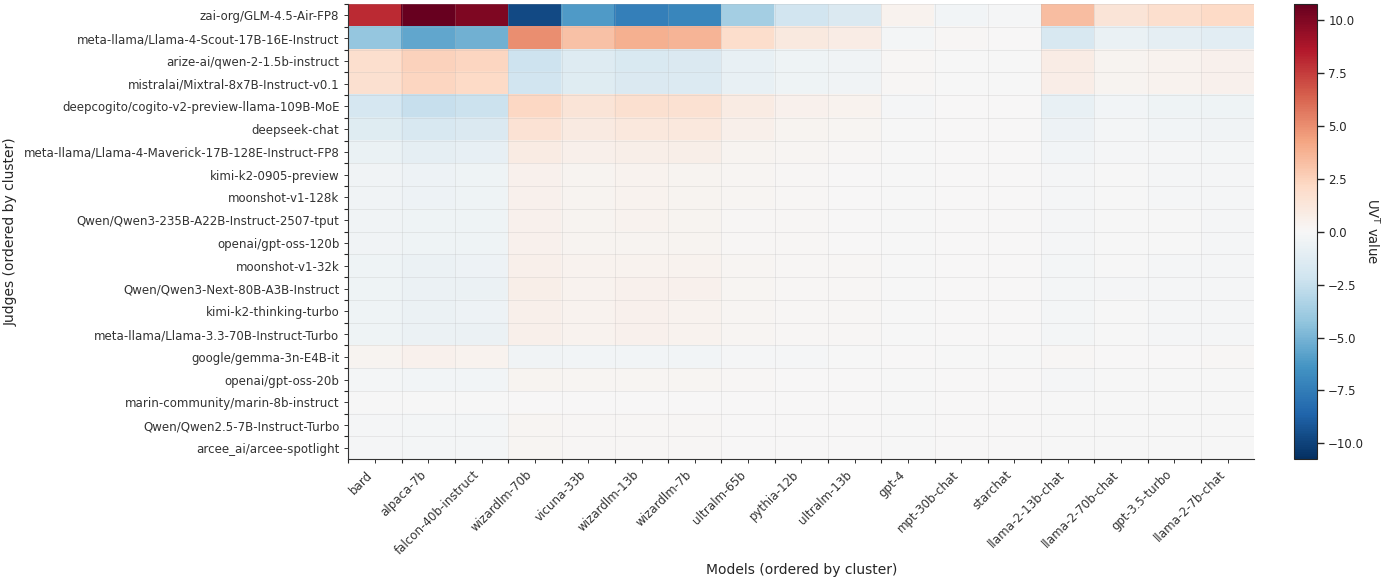

In [138]:
# UV^T heatmap for UltraFeedback
UVT_ultrafeedback = U_est_ultrafeedback @ V_est_ultrafeedback.T
print(f"UV^T shape: {UVT_ultrafeedback.shape}")
print(f"UV^T min: {np.min(UVT_ultrafeedback):.4f}, max: {np.max(UVT_ultrafeedback):.4f}")

# Apply hierarchical clustering
judge_distances_ultrafeedback = pdist(UVT_ultrafeedback, metric='euclidean')
judge_linkage_ultrafeedback = linkage(judge_distances_ultrafeedback, method='ward')
judge_order_ultrafeedback = dendrogram(judge_linkage_ultrafeedback, no_plot=True)['leaves']

model_distances_ultrafeedback = pdist(UVT_ultrafeedback.T, metric='euclidean')
model_linkage_ultrafeedback = linkage(model_distances_ultrafeedback, method='ward')
model_order_ultrafeedback = dendrogram(model_linkage_ultrafeedback, no_plot=True)['leaves']

# Reorder
UVT_clustered_ultrafeedback = UVT_ultrafeedback[judge_order_ultrafeedback, :][:, model_order_ultrafeedback]
clustered_judge_names_ultrafeedback = [judge_names_ultrafeedback[i] for i in judge_order_ultrafeedback]
clustered_model_names_ultrafeedback = [item_names_ultrafeedback[i] for i in model_order_ultrafeedback]

# Create heatmap
sns.set_theme(
    style="ticks",
    context="paper",
    font="DejaVu Sans",
    rc={
        "font.size": 9.0,
        "axes.labelsize": 10.0,
        "axes.titlesize": 11.0,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    },
)

fig, ax = plt.subplots(figsize=(14, 6))
vmax_ultrafeedback = np.max(np.abs(UVT_clustered_ultrafeedback))
vmin_ultrafeedback = -vmax_ultrafeedback

im = ax.imshow(UVT_clustered_ultrafeedback, aspect='auto', cmap='RdBu_r', origin='upper',
               vmin=vmin_ultrafeedback, vmax=vmax_ultrafeedback)

ax.set_xticks(np.arange(len(clustered_model_names_ultrafeedback)))
ax.set_yticks(np.arange(len(clustered_judge_names_ultrafeedback)))
ax.set_xticklabels(clustered_model_names_ultrafeedback, rotation=45, ha='right', fontsize=8.5)
ax.set_yticklabels(clustered_judge_names_ultrafeedback, fontsize=8.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('UV$^\\mathrm{T}$ value', rotation=270, labelpad=12, fontsize=9.5)

ax.set_xlabel('Models (ordered by cluster)', fontsize=10)
ax.set_ylabel('Judges (ordered by cluster)', fontsize=10)

sns.despine(ax=ax, left=False, bottom=False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', length=3, width=0.7, colors='#333333')

ax.set_xticks(np.arange(len(clustered_model_names_ultrafeedback))-.5, minor=True)
ax.set_yticks(np.arange(len(clustered_judge_names_ultrafeedback))-.5, minor=True)
ax.grid(which='minor', color='#B0B0B0', linestyle='-', linewidth=0.45, alpha=0.35)
ax.set_axisbelow(True)

fig.tight_layout()

uvt_output_path_ultrafeedback = OUTPUT_DIR / "paper_ready_ultrafeedback_uvt_heatmap.pdf"
fig.savefig(uvt_output_path_ultrafeedback, dpi=300, bbox_inches='tight')
print(f"\nWrote UltraFeedback UV^T heatmap to: {uvt_output_path_ultrafeedback}")

plt.show()

In [139]:
# ── UltraFeedback: flatten CI dictionaries into ordered arrays ──────────────
mu_half_ci_arr_uf = np.array([
    0.5 * (intervals_mu_ultrafeedback[f"mu[{i}]"]["upper"]
           - intervals_mu_ultrafeedback[f"mu[{i}]"]["lower"])
    for i in range(N_ultrafeedback)
])
gamma_half_ci_arr_uf = np.array([
    0.5 * (intervals_gamma_ultrafeedback[f"gamma[{k}]"]["upper"]
           - intervals_gamma_ultrafeedback[f"gamma[{k}]"]["lower"])
    for k in range(K_ultrafeedback)
])

print(f"UltraFeedback  mu    half-CI: min={mu_half_ci_arr_uf.min():.4f}  max={mu_half_ci_arr_uf.max():.4f}")
print(f"UltraFeedback  gamma half-CI: min={gamma_half_ci_arr_uf.min():.4f}  max={gamma_half_ci_arr_uf.max():.4f}")
print(f"UltraFeedback  mu    range  : [{mu_est_ultrafeedback.min():.4f}, {mu_est_ultrafeedback.max():.4f}]")
print(f"UltraFeedback  gamma range  : [{gamma_est_ultrafeedback.min():.4f}, {gamma_est_ultrafeedback.max():.4f}]")


UltraFeedback  mu    half-CI: min=0.1124  max=0.5230
UltraFeedback  gamma half-CI: min=0.1780  max=0.4472
UltraFeedback  mu    range  : [-1.0715, 1.4626]
UltraFeedback  gamma range  : [-0.8559, 2.9414]


### UltraFeedback Composite Figure

UltraFeedback has N=17 models and K=20 judges (19 after excluding the extreme judge).
Layout is similar to ChatBot Arena (roughly square heatmap).


UltraFeedback model → family:
  alpaca-7b                                 →  Community
  bard                                      →  Google
  falcon-40b-instruct                       →  Open-Source
  gpt-3.5-turbo                             →  OpenAI
  gpt-4                                     →  OpenAI
  llama-2-13b-chat                          →  Meta
  llama-2-70b-chat                          →  Meta
  llama-2-7b-chat                           →  Meta
  mpt-30b-chat                              →  Open-Source
  pythia-12b                                →  Open-Source
  starchat                                  →  Community
  ultralm-13b                               →  Community
  ultralm-65b                               →  Community
  vicuna-33b                                →  Community
  wizardlm-13b                              →  Community
  wizardlm-70b                              →  Community
  wizardlm-7b                               →  Community


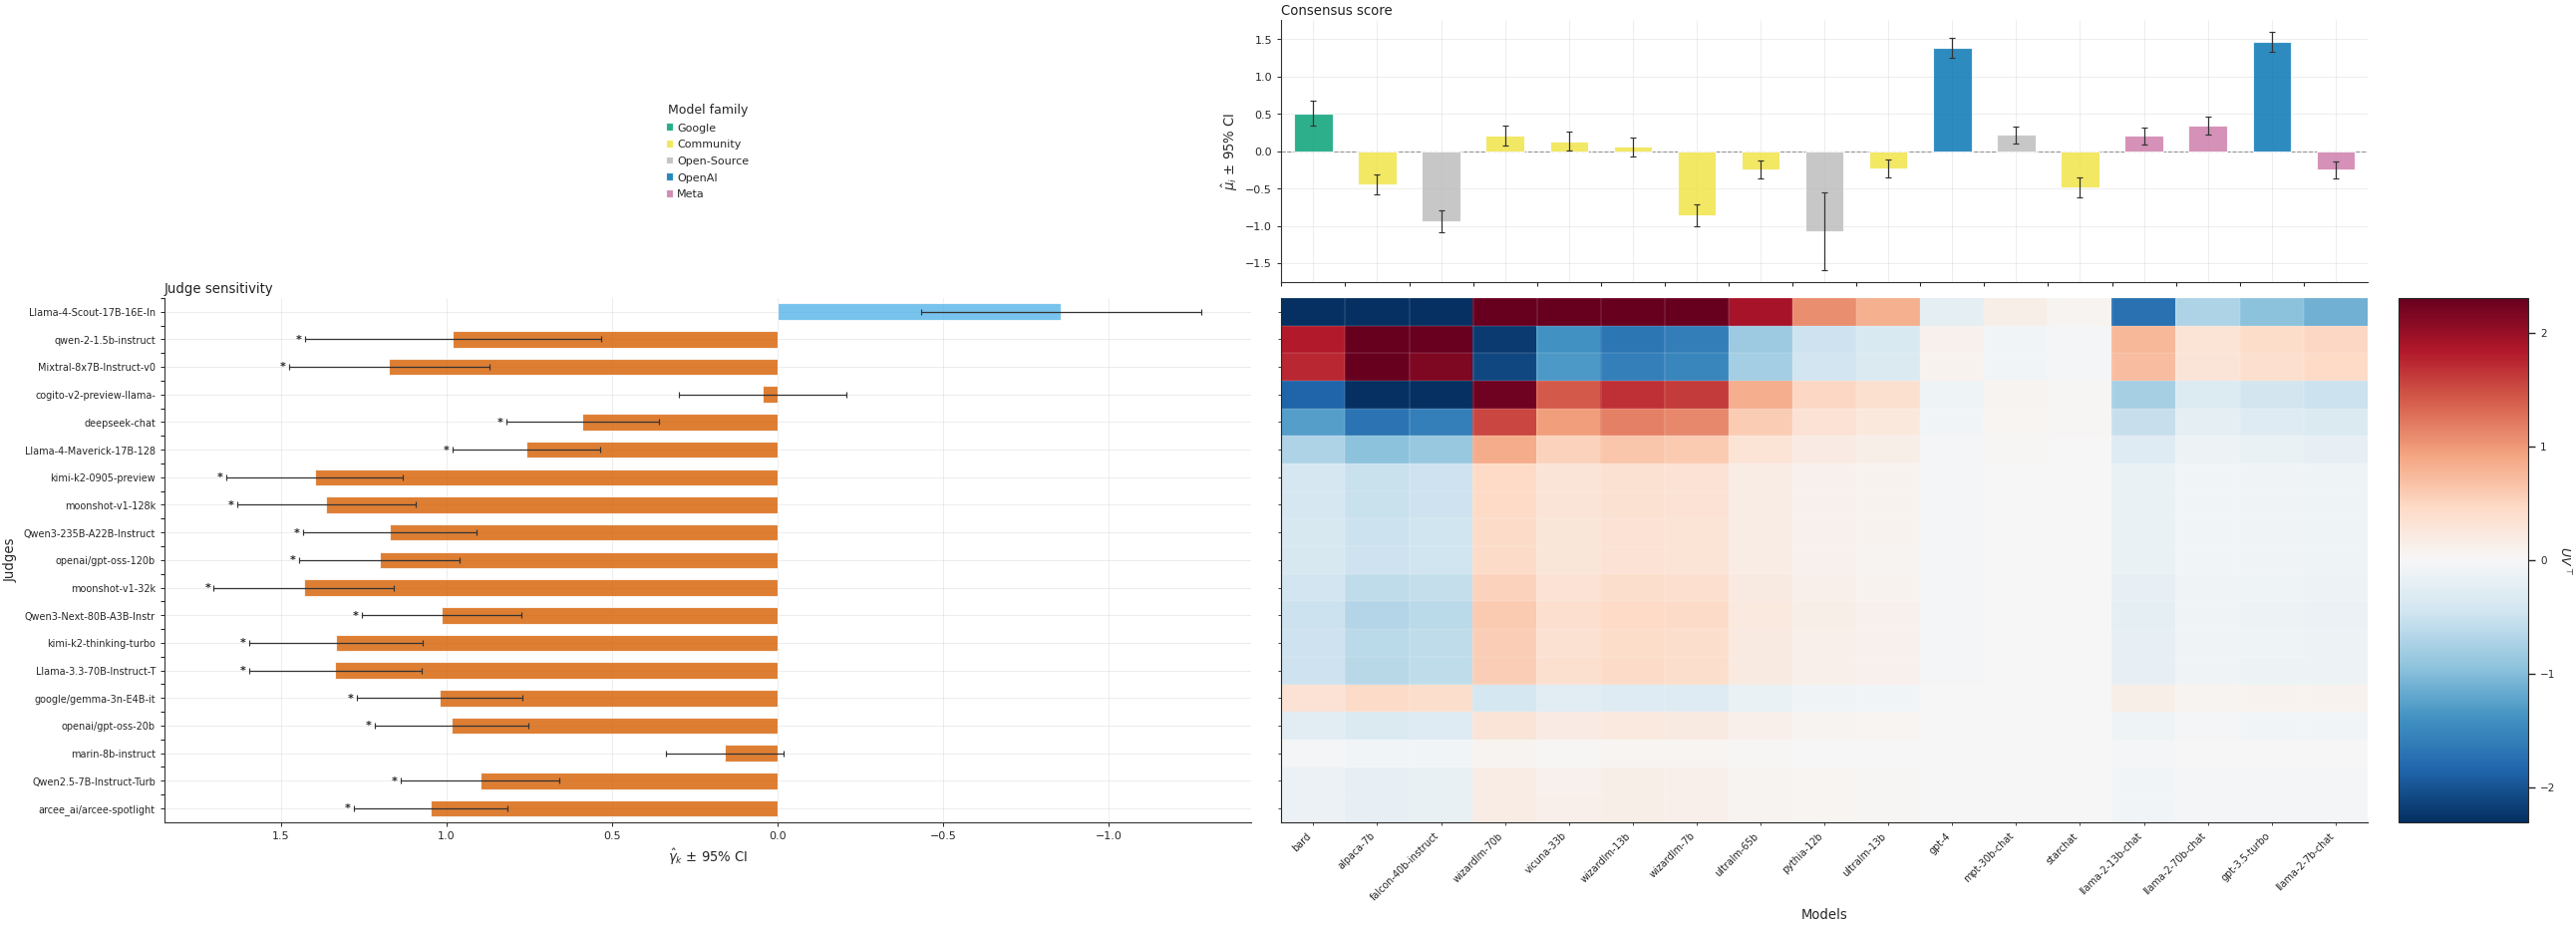

In [140]:
# Sanity-check: family assignment for UltraFeedback models
print("UltraFeedback model → family:")
for mn in sorted(item_names_ultrafeedback):
    print(f"  {mn:<40}  →  {_detect_family(mn)}")

uf_pdf = OUTPUT_DIR / "paper_ready_ultrafeedback_composite.pdf"
uf_png = OUTPUT_DIR / "paper_ready_ultrafeedback_composite.png"

fig_uf = plot_hja_composite(
    mu_est_ultrafeedback, gamma_est_ultrafeedback, U_est_ultrafeedback, V_est_ultrafeedback,
    item_names_ultrafeedback, judge_names_ultrafeedback,
    mu_half_ci_arr_uf, gamma_half_ci_arr_uf,
    extreme_judge_name="zai-org/GLM-4.5-Air-FP8",
    save_pdf=uf_pdf,
    save_png=uf_png,
)


In [141]:
## ── UltraFeedback: Analytical insights ─────────────────────────────────────
print("=" * 68)
print("ULTRAFEEDBACK — HJA ANALYTICAL INSIGHTS")
print("=" * 68)

sorted_idx_uf   = np.argsort(mu_est_ultrafeedback)[::-1]
mu_sorted_uf    = mu_est_ultrafeedback[sorted_idx_uf]
ci_sorted_uf    = mu_half_ci_arr_uf[sorted_idx_uf]
names_sorted_uf = [item_names_ultrafeedback[i] for i in sorted_idx_uf]

print("\n[1] MODEL RANKING  (consensus score ± 95% CI)")
print(f"  {'Rank':>4}  {'Model':<40}  {'μ̂':>8}  {'±CI':>7}")
print("  " + "-" * 62)
for rank, (name, mu_v, ci_v) in enumerate(zip(names_sorted_uf, mu_sorted_uf, ci_sorted_uf), 1):
    print(f"  {rank:>4}  {_shorten(name, 40):<40}  {mu_v:>8.4f}  {ci_v:>7.4f}")

# Tiers
N_uf = len(item_names_ultrafeedback)
tiers_uf, current_tier_uf = [], [0]
for j in range(1, N_uf):
    prev_lower = mu_sorted_uf[current_tier_uf[0]] - ci_sorted_uf[current_tier_uf[0]]
    this_upper = mu_sorted_uf[j] + ci_sorted_uf[j]
    if this_upper < prev_lower:
        tiers_uf.append(current_tier_uf)
        current_tier_uf = [j]
    else:
        current_tier_uf.append(j)
tiers_uf.append(current_tier_uf)

print(f"\n[2] TIER STRUCTURE  ({len(tiers_uf)} tiers by non-overlapping 95% CIs)")
for t_idx, tier in enumerate(tiers_uf, 1):
    tier_names = [_shorten(names_sorted_uf[i], 28) for i in tier]
    score_range = f"{mu_sorted_uf[tier[-1]]:.3f} – {mu_sorted_uf[tier[0]]:.3f}"
    print(f"  Tier {t_idx} ({score_range}):  {', '.join(tier_names)}")

# Judge sensitivity
extreme_judge_name_uf = "zai-org/GLM-4.5-Air-FP8"
filt_idx_uf = [i for i in range(K_ultrafeedback) if judge_names_ultrafeedback[i] != extreme_judge_name_uf]
filt_jnames_uf   = [judge_names_ultrafeedback[i] for i in filt_idx_uf]
gamma_filt_uf    = gamma_est_ultrafeedback[filt_idx_uf]
gamma_ci_filt_uf = gamma_half_ci_arr_uf[filt_idx_uf]

sig_high_uf  = [(j, g, c) for j, g, c in zip(filt_jnames_uf, gamma_filt_uf, gamma_ci_filt_uf) if (g - c) > 0]
sig_low_uf   = [(j, g, c) for j, g, c in zip(filt_jnames_uf, gamma_filt_uf, gamma_ci_filt_uf) if (g + c) < 0]
uncertain_uf = [(j, g, c) for j, g, c in zip(filt_jnames_uf, gamma_filt_uf, gamma_ci_filt_uf) if (g - c) <= 0 <= (g + c)]

print(f"\n[3] JUDGE SENSITIVITY  (γ̂ with 95% CI, excluding {extreme_judge_name_uf})")
print(f"  Significantly discriminative (γ > 0): {len(sig_high_uf)}/{len(filt_idx_uf)}")
print(f"  Significantly contrarian   (γ < 0): {len(sig_low_uf)}/{len(filt_idx_uf)}")
print(f"  CI includes 0 (uncertain):            {len(uncertain_uf)}/{len(filt_idx_uf)}")
if sig_high_uf:
    top_judges_uf = sorted(sig_high_uf, key=lambda x: -x[1])[:5]
    print("  Top-5 most discriminative judges:")
    for jname, gv, cv in top_judges_uf:
        print(f"    {_shorten(jname, 40):<40}  γ̂={gv:+.4f}  ±{cv:.4f}")
if sig_low_uf:
    print("  Contrarian judges (γ < 0):")
    for jname, gv, cv in sorted(sig_low_uf, key=lambda x: x[1])[:3]:
        print(f"    {_shorten(jname, 40):<40}  γ̂={gv:+.4f}  ±{cv:.4f}")

# UV^T heterogeneity
UVT_uf = (U_est_ultrafeedback @ V_est_ultrafeedback.T)[filt_idx_uf, :]
row_std_uf = UVT_uf.std(axis=1)
col_std_uf = UVT_uf.std(axis=0)

print(f"\n[4] UV^T HETEROGENEITY")
print("  Judges with most heterogeneous model preferences:")
for i in np.argsort(row_std_uf)[::-1][:5]:
    print(f"    {_shorten(filt_jnames_uf[i], 40):<40}  row-std={row_std_uf[i]:.4f}")
print("  Models with most divergent judge opinions:")
for i in np.argsort(col_std_uf)[::-1][:min(10, N_uf)]:
    print(f"    {_shorten(item_names_ultrafeedback[i], 40):<40}  col-std={col_std_uf[i]:.4f}")

print("\n" + "=" * 68)


ULTRAFEEDBACK — HJA ANALYTICAL INSIGHTS

[1] MODEL RANKING  (consensus score ± 95% CI)
  Rank  Model                                           μ̂      ±CI
  --------------------------------------------------------------
     1  gpt-3.5-turbo                               1.4626   0.1342
     2  gpt-4                                       1.3863   0.1318
     3  bard                                        0.5079   0.1697
     4  llama-2-70b-chat                            0.3452   0.1179
     5  mpt-30b-chat                                0.2206   0.1129
     6  wizardlm-70b                                0.2075   0.1325
     7  llama-2-13b-chat                            0.2070   0.1124
     8  vicuna-33b                                  0.1347   0.1225
     9  wizardlm-13b                                0.0606   0.1276
    10  ultralm-13b                                -0.2326   0.1173
    11  ultralm-65b                                -0.2462   0.1229
    12  llama-2-7b-chat         

## In-House Data Analysis

In [142]:
# Load in-house dataset
print("Loading in-house dataset...")
inhouse_path = EXPERIMENTS_DIR / "data" / "in_house_data.json"
dataset_inhouse = load_real_dataset(str(inhouse_path))

summary_inhouse = dataset_inhouse["summary"]
processed_records_inhouse = dataset_inhouse["processed"]
item_names_inhouse = dataset_inhouse["item_names"]
judge_names_inhouse = dataset_inhouse["judge_names"]
N_inhouse = len(item_names_inhouse)
K_inhouse = len(judge_names_inhouse)

print(f"In-House: N={N_inhouse}, K={K_inhouse}")
print(f"  Total raw records: {summary_inhouse['total_records']}")
print(f"  Usable records: {summary_inhouse['usable_records']}")
print(f"  Unknown labels skipped: {summary_inhouse['unknown_count']}")
print(f"  Tie labels kept: {summary_inhouse['tie_count']}")

n_ijk_inhouse, y_ijk_inhouse = processed_records_to_aggregated(
    processed_records_inhouse, N_inhouse, K_inhouse
)

# Fit HJA model
fit_result_inhouse = fit_proposed(
    N_inhouse, K_inhouse, r_model=1,
    n_ijk=n_ijk_inhouse, y_ijk=y_ijk_inhouse,
    max_steps=40, tol=5e-5, tau=30.0
)

mu_est_inhouse = fit_result_inhouse["mu"]
gamma_est_inhouse = fit_result_inhouse["gamma"]
U_est_inhouse = fit_result_inhouse["U"]
V_est_inhouse = fit_result_inhouse["V"]

# Compute UQ for mu (consensus_score targets)
targets_mu_inhouse = [
    {"type": "consensus_score", "i": i, "label": f"mu[{i}]"}
    for i in range(N_inhouse)
]
uq_results_mu_inhouse = uncertainty_quantification(
    gamma_est_inhouse, mu_est_inhouse, U_est_inhouse, V_est_inhouse,
    n_ijk_inhouse, targets_mu_inhouse, alpha=0.05
)
intervals_mu_inhouse = {
    interval["label"]: interval for interval in uq_results_mu_inhouse["intervals"]
}

# Compute UQ for gamma targets
targets_gamma_inhouse = [
    {"type": "gamma", "k": k, "label": f"gamma[{k}]"}
    for k in range(K_inhouse)
]
uq_results_gamma_inhouse = uncertainty_quantification(
    gamma_est_inhouse, mu_est_inhouse, U_est_inhouse, V_est_inhouse,
    n_ijk_inhouse, targets_gamma_inhouse, alpha=0.05
)
intervals_gamma_inhouse = {
    interval["label"]: interval for interval in uq_results_gamma_inhouse["intervals"]
}

# Create ranking dataframe for in-house
ranking_data_inhouse = []
for i, item_name in enumerate(item_names_inhouse):
    score = mu_est_inhouse[i]
    interval = intervals_mu_inhouse[f"mu[{i}]"]
    half_ci = 0.5 * (interval["upper"] - interval["lower"])
    ranking_data_inhouse.append({
        "Model": item_name,
        "Score": f"${score:.4f} \\pm {half_ci:.4f}$",
        "score_numeric": score
    })

ranking_df_inhouse = pd.DataFrame(ranking_data_inhouse).sort_values('score_numeric', ascending=False)
ranking_df_inhouse['Rank'] = range(1, len(ranking_df_inhouse) + 1)
ranking_df_inhouse = ranking_df_inhouse[['Rank', 'Model', 'Score']].reset_index(drop=True)

print("\n=== In-House Data Model Rankings ===")
print(ranking_df_inhouse.to_string(index=False))

# Create gamma dataframe for in-house
gamma_data_inhouse = []
for k, judge_name in enumerate(judge_names_inhouse):
    gamma = gamma_est_inhouse[k]
    interval = intervals_gamma_inhouse[f"gamma[{k}]"]
    half_ci = 0.5 * (interval["upper"] - interval["lower"])
    gamma_data_inhouse.append({
        "Judge": judge_name,
        "Gamma": f"${gamma:.4f} \\pm {half_ci:.4f}$",
        "gamma_numeric": gamma
    })

gamma_df_inhouse = pd.DataFrame(gamma_data_inhouse).sort_values('gamma_numeric', ascending=False)
gamma_df_inhouse = gamma_df_inhouse[['Judge', 'Gamma']].reset_index(drop=True)

print("\n=== In-House Data Judge Reliability (gamma) ===")
print(gamma_df_inhouse.to_string(index=False))


Loading in-house dataset...
In-House: N=45, K=18
  Total raw records: 36000
  Usable records: 35839
  Unknown labels skipped: 161
  Tie labels kept: 1782

=== In-House Data Model Rankings ===
 Rank                                             Model                Score
    1                  Qwen/Qwen3-Next-80B-A3B-Instruct  $1.0060 \pm 0.1013$
    2                               openai/gpt-oss-120b  $0.8604 \pm 0.0964$
    3                  moonshotai/Kimi-K2-Instruct-0905  $0.7952 \pm 0.0978$
    4                       moonshotai/Kimi-K2-Thinking  $0.7871 \pm 0.0967$
    5           Qwen/Qwen3-235B-A22B-Instruct-2507-tput  $0.7290 \pm 0.0935$
    6                                   zai-org/GLM-4.6  $0.6975 \pm 0.0946$
    7                                openai/gpt-oss-20b  $0.5335 \pm 0.0900$
    8                         deepseek-ai/DeepSeek-V3.1  $0.4758 \pm 0.0915$
    9                           deepseek-ai/DeepSeek-R1  $0.4414 \pm 0.0902$
   10                           deepse

UV^T shape: (18, 45)
UV^T min: -1.2725, max: 0.7009



Wrote In-House UV^T heatmap to: /home/jinhongd/projects/HJA-Ranking/experiments/results/paper_ready_simulation_plots/paper_ready_inhouse_uvt_heatmap.pdf


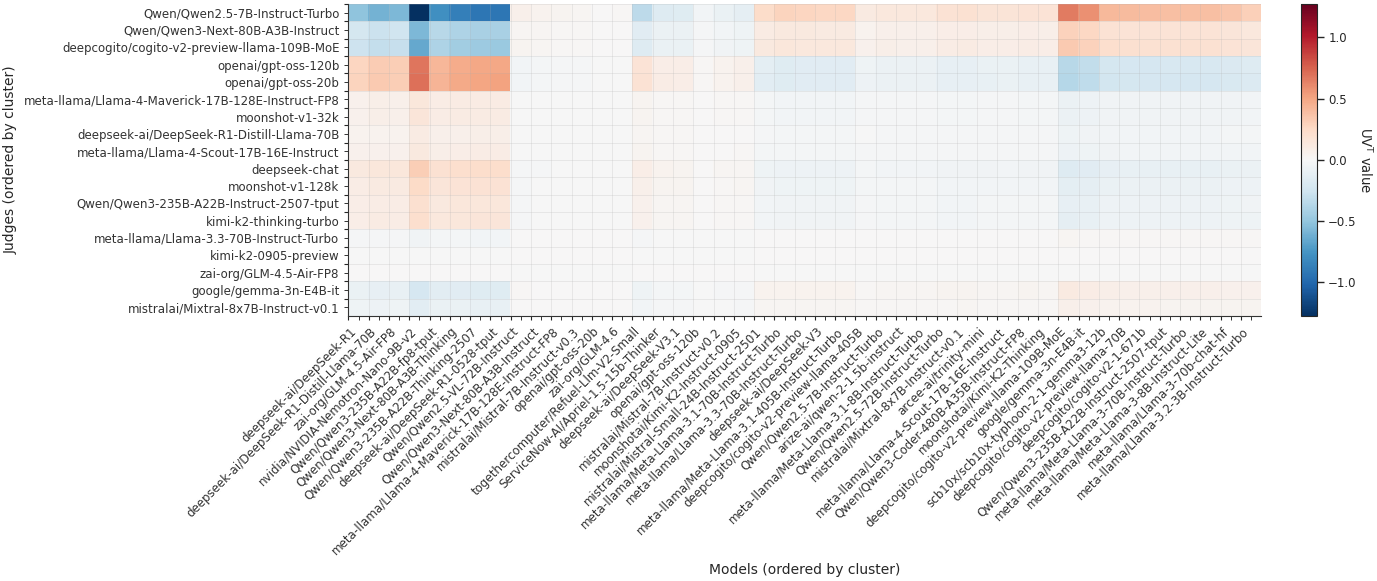

In [143]:
# UV^T heatmap for in-house data
UVT_inhouse = U_est_inhouse @ V_est_inhouse.T
print(f"UV^T shape: {UVT_inhouse.shape}")
print(f"UV^T min: {np.min(UVT_inhouse):.4f}, max: {np.max(UVT_inhouse):.4f}")

# Apply hierarchical clustering
judge_distances_inhouse = pdist(UVT_inhouse, metric='euclidean')
judge_linkage_inhouse = linkage(judge_distances_inhouse, method='ward')
judge_order_inhouse = dendrogram(judge_linkage_inhouse, no_plot=True)['leaves']

model_distances_inhouse = pdist(UVT_inhouse.T, metric='euclidean')
model_linkage_inhouse = linkage(model_distances_inhouse, method='ward')
model_order_inhouse = dendrogram(model_linkage_inhouse, no_plot=True)['leaves']

# Reorder
UVT_clustered_inhouse = UVT_inhouse[judge_order_inhouse, :][:, model_order_inhouse]
clustered_judge_names_inhouse = [judge_names_inhouse[i] for i in judge_order_inhouse]
clustered_model_names_inhouse = [item_names_inhouse[i] for i in model_order_inhouse]

# Create heatmap
sns.set_theme(
    style="ticks",
    context="paper",
    font="DejaVu Sans",
    rc={
        "font.size": 9.0,
        "axes.labelsize": 10.0,
        "axes.titlesize": 11.0,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    },
)

fig, ax = plt.subplots(figsize=(14, 6))
vmax_inhouse = np.max(np.abs(UVT_clustered_inhouse))
vmin_inhouse = -vmax_inhouse

im = ax.imshow(UVT_clustered_inhouse, aspect='auto', cmap='RdBu_r', origin='upper',
               vmin=vmin_inhouse, vmax=vmax_inhouse)

ax.set_xticks(np.arange(len(clustered_model_names_inhouse)))
ax.set_yticks(np.arange(len(clustered_judge_names_inhouse)))
ax.set_xticklabels(clustered_model_names_inhouse, rotation=45, ha='right', fontsize=8.5)
ax.set_yticklabels(clustered_judge_names_inhouse, fontsize=8.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('UV$^\\mathrm{T}$ value', rotation=270, labelpad=12, fontsize=9.5)

ax.set_xlabel('Models (ordered by cluster)', fontsize=10)
ax.set_ylabel('Judges (ordered by cluster)', fontsize=10)

sns.despine(ax=ax, left=False, bottom=False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', length=3, width=0.7, colors='#333333')

ax.set_xticks(np.arange(len(clustered_model_names_inhouse))-.5, minor=True)
ax.set_yticks(np.arange(len(clustered_judge_names_inhouse))-.5, minor=True)
ax.grid(which='minor', color='#B0B0B0', linestyle='-', linewidth=0.45, alpha=0.35)
ax.set_axisbelow(True)

fig.tight_layout()

uvt_output_path_inhouse = OUTPUT_DIR / "paper_ready_inhouse_uvt_heatmap.pdf"
fig.savefig(uvt_output_path_inhouse, dpi=300, bbox_inches='tight')
print(f"\nWrote In-House UV^T heatmap to: {uvt_output_path_inhouse}")

plt.show()